In [1]:
# %matplotlib ipympl

In [2]:
# ======================================================================
# DIELECTRIC LOSS INPUTS (STARTING VALUES TO SWEEP)
# ======================================================================

# Recommended starting points:
#   tan_delta_Si ~ 5e-6 for good crystalline Si at mK
#   tan_delta_JJ and tan_delta_SQUID are much less certain -> sweep them
tan_delta_Si = 5e-6
tan_delta_JJ = 1e-6
tan_delta_SQUID = 1e-6

In [3]:
import numpy as np
import scipy.constants as const

import scqubits as scq
hbar = const.hbar


# 1. Define physical constants and conversion factors
h = const.h                      # Planck constant in J*s
e = const.e                      # Elementary charge in C
Phi0 = h / (2 * e)               # Magnetic flux quantum in Wb
GHz = 1e9                        # Conversion for Hz to GHz
fF_to_F = 1e-15                  # femtoFarad to Farad

# 2. Define input parameters
fp_target_GHz = 40          # Target plasma frequency in GHz: 50 GHz (0.14 Torr) to 55 GHz (0.07 Torr)
wp_target = 2 * np.pi * fp_target_GHz * GHz # Target angular frequency in rad/s

# Junction dimensions
W_um = 0.260                       # Width in um (260 nm)
L_um = 1                         # Length in um 2.8 is the largest
N = 20              # number of cells
# for N in [120]:

C_area_fF_per_um2 = 45.0         # Capacitance per unit area in fF/um^2 (Assumed)

# 3. Calculate Junction Capacitance (C_J)
Area_um2 = W_um * L_um
CJ = C_area_fF_per_um2 * Area_um2 * fF_to_F # Junction capacitance C in Farads (F)

# 4. Calculate Josephson Inductance (L_J)
# Formula: wp = 1/sqrt(LJ * CJ) => LJ = 1 / (wp^2 * CJ)
LJ = 1.0 / (wp_target**2 * CJ)  # Josephson Inductance L in Henries (H)

# 5. Calculate Josephson Energy (E_J)
# Formula: EJ = (Phi0 / (2*pi))^2 / LJ
EJ = (Phi0 / (2 * np.pi))**2 / LJ # Josephson Energy EJ in Joules (J)
EJ_GHz = EJ / h  / GHz              # Josephson Energy EJ in GHz

# 6. Calculate Charging Energy (E_C)
# Formula: EC = e^2 / (2 * (2 * CJ))
EC = e**2 / (2 * CJ)             # Charging Energy EC in Joules (J)
EC_GHz = EC / h  / GHz                  # Charging Energy EC in GHz


# Cg_over_CJ = 0.10       # stray-to-ground ratio
Cg = 4.5e-18 ###Cg_over_CJ * CJ

# --- Chain design targets (edit here) ---
a = W_um * 1e-6                # cell pitch [m] (for bookkeeping; not critical here)


#########################################
R = 50.0                       # target wave impedance [Ohm]
########################################


# # 2. Define input parameters
# fp_target_GHz = 30          # Target plasma frequency in GHz: 50 GHz (0.14 Torr) to 55 GHz (0.07 Torr)
# wp_target = 2 * np.pi * fp_target_GHz * GHz # Target angular frequency in rad/s


# Qubit junction dimensions
W_um = 0.260                       # Width in um (260 nm)
L_um = 2.819  #+0.040                      # Length in um
d_length = 0.027847 #+ 0.001

L1_um = L_um*(1-d_length)
L2_um = L_um*(1+d_length)

Area_um2 = W_um * L_um
# CJ_qubit = C_area_fF_per_um2 * Area_um2 * fF_to_F # Junction capacitance C in Farads (F)

CJ1 = C_area_fF_per_um2 * W_um * L1_um * fF_to_F
CJ2 = C_area_fF_per_um2 * W_um * L2_um * fF_to_F

LJ1 = 1.0 / (wp_target**2 * CJ1)  # Josephson Inductance L in Henries (H)
LJ2 = 1.0 / (wp_target**2 * CJ2)  # Josephson Inductance L in Henries (H)

# LJ_qubit = 1.0 / (wp_target**2 * CJ_qubit)  # Josephson Inductance L in Henries (H)

EJ1 = (Phi0 / (2 * np.pi))**2 / LJ1 # Josephson Energy EJ in Joules (J) 
EJ1_GHz = EJ1 / h  / GHz              # Josephson Energy EJ in GHz

EJ2 = (Phi0 / (2 * np.pi))**2 / LJ2 # Josephson Energy EJ in Joules (J) 
EJ2_GHz = EJ2 / h  / GHz              # Josephson Energy EJ in GHz

# EJ_qubit = 2*(Phi0 / (2 * np.pi))**2 / LJ_qubit # Josephson Energy EJ in Joules (J) # factor of 2 for the SQUID
# EJ_qubit_GHz = EJ_qubit / h  / GHz              # Josephson Energy EJ in GHz

EJ_qubit_GHz = (EJ1_GHz + EJ2_GHz) # total EJ of the SQUID is the sum of the two junctions

EC1 = e**2 / (2 * CJ1)             # Charging Energy EC in Joules (J) 
EC1_GHz = EC1 / h  / GHz                  # Charging Energy EC in GHz
EC2 = e**2 / (2 * CJ2)             # Charging Energy EC in Joules (J)
EC2_GHz = EC2 / h  / GHz                  # Charging Energy EC in GHz

EC_qubit = e**2 / (2 * (CJ1 + CJ2))             # Charging Energy EC in Joules (J)
EC_qubit_GHz = EC_qubit / h  / GHz                  # Charging Energy EC in GHz

# EC_qubit = e**2 / (2 * CJ_qubit * 2)             # Charging Energy EC in Joules (J) # factor of 2 for the SQUID since the two junctions are in parallel, so total C is 2*CJ_qubit
# EC_qubit_GHz = EC_qubit / h  / GHz                  # Charging Energy EC in GHz


d = (EJ2 - EJ1)/(EJ2 + EJ1)

Phi_ext = 0.5*Phi0


Cc = 0.16e-15 #0.1e-15             # [F]

N_SQUID = 10 #N//2


qubit_params = {
    'EJ_GHz': EJ_qubit_GHz,
    'EC_GHz': EC_qubit_GHz,
    'd': d,
    'ng': 0.0,
    'ncut': 20,
    'truncated_dim': 10,
    'CJ': CJ1 + CJ2, # total capacitance of the SQUID (two junctions in parallel)
}

print("true d = ", d)

true d =  0.027846999999999934


In [4]:
np.sqrt(8*EJ_qubit_GHz*EC_qubit_GHz)

np.float64(39.99999999999999)

In [5]:
L1_um, L2_um

(2.740499307, 2.897500693)

In [6]:
MODE_IDX = 1
FREQ1, FREQ2, KAPPA, T1_PURCELL, TPHI_CHARGE, G_COUPLING = None, None, None, None, None, None


In [7]:
print("Junction parameters:")
print(f"  C_J = {CJ*1e15:.2f} fF")
print(f"  L_J = {LJ*1e9:.2f} nH")
print(f"  E_J = {EJ_GHz:.2f} GHz")
print(f"  E_C = {EC_GHz:.2f} GHz")
print(f"  E_J/E_C = {EJ_GHz/EC_GHz:.2f}")
print(f"  C_g = {Cg*1e18:.2f} aF")
print()
print("Qubit parameters:")
print(f"  C_J1 = {CJ1*1e15:.2f} fF")
print(f"  C_J2 = {CJ2*1e15:.2f} fF")
print(f"  C_J_avg = {(CJ1+CJ2)/2*1e15:.2f} fF")
print(f"  L_J1 = {LJ1*1e9:.2f} nH")
print(f"  L_J2 = {LJ2*1e9:.2f} nH")
print(f"  L_J_avg = {(LJ1+LJ2)/2*1e9:.2f} nH")
print(f"  E_J = {EJ_qubit_GHz:.2f} GHz")
print(f"  E_C = {EC_qubit_GHz:.2f} GHz")
print(f"  E_J/E_C = {EJ_qubit_GHz/EC_qubit_GHz:.2f}")
print(EJ1_GHz, EJ2_GHz)

Junction parameters:
  C_J = 11.70 fF
  L_J = 1.35 nH
  E_J = 120.80 GHz
  E_C = 1.66 GHz
  E_J/E_C = 72.97
  C_g = 4.50 aF

Qubit parameters:
  C_J1 = 32.06 fF
  C_J2 = 33.90 fF
  C_J_avg = 32.98 fF
  L_J1 = 0.49 nH
  L_J2 = 0.47 nH
  L_J_avg = 0.48 nH
  E_J = 681.09 GHz
  E_C = 0.29 GHz
  E_J/E_C = 2319.44
331.0631108644787 350.02949670753657


In [8]:
EJ_qubit_GHz_half_flux = EJ_qubit_GHz * np.cos(np.pi * Phi_ext / Phi0) * np.sqrt(1 + d**2 * np.tan(np.pi * Phi_ext / Phi0)**2)

print("SQUID EJ at half-flux with an:")
print(f"  asymmetry d = {d:.2f}")
print(f"  E_J_SQUID = {EJ_qubit_GHz_half_flux:.2f} GHz")
print(f"EJ/EC at half-flux with an asymmetry d = {d:.2f}:",
      EJ_qubit_GHz * np.cos(np.pi * Phi_ext / Phi0) * np.sqrt(1 + d**2 * np.tan(np.pi * Phi_ext / Phi0)**2) / EC_qubit_GHz) 

print(f"Freq at half-flux with an asymmetry d = {d:.2f}:",
      np.sqrt(8 * EJ_qubit_GHz * np.cos(np.pi * Phi_ext / Phi0) * np.sqrt(1 + d**2 * np.tan(np.pi * Phi_ext / Phi0)**2) * EC_qubit_GHz) - EC_qubit_GHz)

# EJ1 and EJ2 at Phi_ext = 0.5*Phi0 with an asymmetry d = 0.03
EJ1_half_flux = EJ_qubit_GHz_half_flux * (1-d)/2
EJ2_half_flux = EJ_qubit_GHz_half_flux * (1+d)/2
print(f"EJ1 at half-flux with an asymmetry d = {d:.2f}: {EJ1_half_flux:.2f} GHz")
print(f"EJ2 at half-flux with an asymmetry d = {d:.2f}: {EJ2_half_flux:.2f} GHz")
print(f"Total EJ at half-flux with an asymmetry d = {d:.2f}: {EJ1_half_flux + EJ2_half_flux:.2f} GHz")

LJ1_half_flux = (Phi0 / (2 * np.pi))**2 / (EJ1_half_flux * h * GHz)
LJ2_half_flux = (Phi0 / (2 * np.pi))**2 / (EJ2_half_flux * h * GHz)
print(f"LJ1 at half-flux with an asymmetry d = {d:.2f}: {LJ1_half_flux*1e9:.2f} nH")
print(f"LJ2 at half-flux with an asymmetry d = {d:.2f}: {LJ2_half_flux*1e9:.2f} nH")

print(f"Relative difference in inductances at half-flux with an asymmetry d = {d:.2f}: {(LJ1_half_flux - LJ2_half_flux)/(LJ1_half_flux + LJ2_half_flux):.2f}")
print(f"average LJ at half-flux with an asymmetry d = {d:.2f}: {(LJ1_half_flux + LJ2_half_flux)/2*1e9:.2f} nH")
print(f"average CJ at half-flux with an asymmetry d = {d:.2f}: {(CJ1 + CJ2)/2*1e15:.2f} fF")

SQUID EJ at half-flux with an:
  asymmetry d = 0.03
  E_J_SQUID = 18.97 GHz
EJ/EC at half-flux with an asymmetry d = 0.03: 64.5893259503262
Freq at half-flux with an asymmetry d = 0.03: 6.381322340675199
EJ1 at half-flux with an asymmetry d = 0.03: 9.22 GHz
EJ2 at half-flux with an asymmetry d = 0.03: 9.75 GHz
Total EJ at half-flux with an asymmetry d = 0.03: 18.97 GHz
LJ1 at half-flux with an asymmetry d = 0.03: 17.73 nH
LJ2 at half-flux with an asymmetry d = 0.03: 16.77 nH
Relative difference in inductances at half-flux with an asymmetry d = 0.03: 0.03
average LJ at half-flux with an asymmetry d = 0.03: 17.25 nH
average CJ at half-flux with an asymmetry d = 0.03: 32.98 fF


In [9]:
L_per_sheet = 1e-12 # 1 pH per square, for bookkeeping;

SQUIDLidL = 2
SQUIDLidW = 10

SQUIDJJL = 5
SQUIDJJW = 1

chainW = 2.8
SQUIDislandL = 3 

num_sheets_per_SQUID_half = 0.5*SQUIDLidW/SQUIDLidL + SQUIDJJL/SQUIDJJW + SQUIDislandL/chainW

L_SQUID_half = num_sheets_per_SQUID_half * L_per_sheet

EL_SQUID_half = (Phi0 / (2 * np.pi))**2 / L_SQUID_half
EL_SQUID_half_GHz = EL_SQUID_half / h / GHz

(EJ1_GHz**2 / (4*EL_SQUID_half_GHz) + EJ2_GHz**2 / (4*EL_SQUID_half_GHz)) / abs(EJ1_GHz-EJ2_GHz), EL_SQUID_half_GHz, L_SQUID_half*1e12

(0.16043979807051306, 19070.5098274578, 8.571428571428571)

In [10]:
import numpy as np
import pandas as pd
from pathlib import Path
import re

# ======================================================================
# FULL HFSS / Q3D MAXWELL CAPACITANCE MATRIX IMPORT
# ======================================================================
#
# New logic:
#   - do NOT reduce the HFSS file to only Cg_array and Cc_array
#   - load the complete Maxwell capacitance block
#   - remove the explicit ground conductor
#   - reorder the remaining conductors into the circuit-node order:
#         node 0: feed
#         node 1..N+1: physical chain/SQUID nodes
#   - use this full C matrix directly in build_chain_plain/build_chain_squid/Y_env
#
# The legacy Cc_array and Cg_array are still produced for:
#   - quick plotting/debugging
#   - old fallback calculations
#   - dielectric-participation estimates that still need a per-node Cg proxy
#
# Units:
#   HFSS/Q3D CSV here is in fF; C_HFSS is converted to Farads.

def _find_capacitance_header(path, gnd_name="gnd"):
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    for i, ln in enumerate(lines):
        # Typical HFSS/Q3D export header:
        # ,feed,first_island,gnd,island,...
        if ln.startswith(",") and gnd_name in ln:
            return i
    raise RuntimeError(
        "Could not detect capacitance matrix header. "
        "Expected a line starting with ',' and containing the ground conductor name."
    )


def read_hfss_maxwell_matrix_csv(path, gnd_name="gnd", debug=True):
    """
    Read the raw Maxwell capacitance matrix from an HFSS/Q3D CSV.

    Returns
    -------
    Cmax_fF : pd.DataFrame
        Full Maxwell matrix in fF, indexed/columned by conductor names.
        Includes gnd if gnd is present in the file.
    meta : dict
        Header index and basic diagnostics.
    """
    path = Path(path)
    header_idx = _find_capacitance_header(path, gnd_name=gnd_name)

    df = pd.read_csv(path, skiprows=header_idx, header=0)
    df = df.rename(columns={df.columns[0]: "name"})
    df = df.dropna(subset=["name"])
    df["name"] = df["name"].astype(str).str.strip()
    df = df.set_index("name")
    df.columns = [str(c).strip() for c in df.columns]
    df = df.dropna(axis=1, how="all")

    # HFSS sometimes leaves an empty trailing column after the last comma.
    df = df.loc[:, [c for c in df.columns if c and c.lower() != "nan"]]

    # Deduplicate defensively.
    df = df[~df.index.duplicated(keep="first")]
    df = df.loc[:, ~pd.Index(df.columns).duplicated(keep="first")]

    df = df.apply(pd.to_numeric, errors="coerce")

    # Keep only conductors present both as row and column.
    common = [x for x in df.index if x in df.columns]
    df = df.loc[common, common]

    if debug:
        print(f"[HFSS C] file = {path}")
        print(f"[HFSS C] header_idx = {header_idx}")
        print(f"[HFSS C] raw matrix shape = {df.shape}")
        print(f"[HFSS C] first names = {list(df.index[:10])}")
        print(f"[HFSS C] last  names = {list(df.index[-10:])}")

    return df, {"path": str(path), "header_idx": header_idx, "shape": df.shape}


def _sort_island_suffix(names, base):
    """
    Sort right-block names such as:
      island_25, island_25_1, island_25_2, ...
    """
    def key(name):
        if name == f"island_{base}":
            return 0
        m = re.fullmatch(rf"island_{base}_(\d+)", name)
        if m:
            return int(m.group(1)) + 1
        return 10**9
    return sorted(names, key=key)


def infer_hfss_chain_node_order(names,
                                feed_candidates=("feed", "strip", "port"),
                                gnd_name="gnd",
                                squid_lid_names=("SQUID_lid1", "SQUID_lid2"),
                                debug=True):
    """
    Infer the physical node order used by the chain model.

    The generator used in this project typically names nodes like:
      feed, first_island, island, island_1, ..., island_8,
      island_25, island_25_1, ..., last_island, SQUID_lid1, SQUID_lid2, gnd

    We map that to:
      feed,
      first_island, island, island_1, ..., island_8,
      SQUID_lid1, SQUID_lid2,
      island_25, island_25_1, ..., last_island

    This makes the SQUID branch the branch between SQUID_lid1 and SQUID_lid2.
    """
    names = list(names)

    feed_name = None
    for cand in feed_candidates:
        if cand in names:
            feed_name = cand
            break
    if feed_name is None:
        for nm in names:
            low = nm.lower()
            if any(c in low for c in feed_candidates):
                feed_name = nm
                break
    if feed_name is None:
        raise RuntimeError(f"Could not find feed conductor. Tried {feed_candidates}.")

    squid_lids = [nm for nm in squid_lid_names if nm in names]

    # Detect right-block bases from names like island_25_3.
    right_bases = []
    for nm in names:
        m = re.fullmatch(r"island_(\d+)_(\d+)", nm)
        if m:
            right_bases.append(int(m.group(1)))
    right_base = min(right_bases) if right_bases else None

    left_nodes = []
    if "first_island" in names:
        left_nodes.append("first_island")
    if "island" in names:
        left_nodes.append("island")

    # island_1, island_2, ... before the right block
    numbered_single = []
    for nm in names:
        m = re.fullmatch(r"island_(\d+)", nm)
        if not m:
            continue
        val = int(m.group(1))
        if right_base is None or val < right_base:
            numbered_single.append((val, nm))
    left_nodes.extend([nm for _, nm in sorted(numbered_single)])

    right_nodes = []
    if right_base is not None:
        candidates = [nm for nm in names if nm == f"island_{right_base}" or re.fullmatch(rf"island_{right_base}_\d+", nm)]
        right_nodes = _sort_island_suffix(candidates, right_base)
    else:
        # No SQUID split naming detected: use any remaining island_* not already used.
        used = set(left_nodes)
        candidates = [nm for nm in names if nm.startswith("island_") and nm not in used]
        right_nodes = sorted(candidates)

    if "last_island" in names:
        right_nodes.append("last_island")

    chain_nodes = []
    for group in (left_nodes, squid_lids, right_nodes):
        for nm in group:
            if nm in names and nm not in chain_nodes and nm not in (feed_name, gnd_name):
                chain_nodes.append(nm)

    # Fallback if names are simpler than expected.
    if len(chain_nodes) == 0:
        chain_nodes = [nm for nm in names if nm not in (feed_name, gnd_name)]

    node_order = [feed_name] + chain_nodes

    if len(squid_lids) == 2:
        # 1-based circuit-node index of SQUID_lid1 in node_order.
        # Branch j connects node j to node j+1, with node 0 = feed.
        N_SQUID_from_order = node_order.index(squid_lids[0])
    else:
        N_SQUID_from_order = len(chain_nodes) // 2

    info = {
        "feed_name": feed_name,
        "gnd_name": gnd_name,
        "squid_lids": squid_lids,
        "right_base": right_base,
        "chain_nodes": chain_nodes,
        "node_order": node_order,
        "N": len(chain_nodes) - 1,             # number of adjacent branches in this node order
        "N_nodes_chain": len(chain_nodes),     # equals N+1
        "N_SQUID": N_SQUID_from_order,
    }

    if debug:
        print(f"[HFSS C] feed_name = {feed_name}")
        print(f"[HFSS C] squid_lids = {squid_lids}")
        print(f"[HFSS C] right_base = {right_base}")
        print(f"[HFSS C] chain nodes ({len(chain_nodes)}): {chain_nodes}")
        print(f"[HFSS C] inferred N = {info['N']}, inferred N_SQUID = {info['N_SQUID']}")

    return node_order, info


def build_reduced_hfss_C_matrix(path,
                                unit_scale=1e-15,
                                gnd_name="gnd",
                                feed_candidates=("feed", "strip", "port"),
                                debug=True):
    """
    Build the complete reduced capacitance matrix used by the circuit solver.

    C_HFSS = full Maxwell block with gnd removed and conductors reordered.
    This is the capacitance matrix for nodal variables:
        [feed, chain_node_1, ..., chain_node_{N+1}]
    """
    Cmax_fF, meta = read_hfss_maxwell_matrix_csv(path, gnd_name=gnd_name, debug=debug)
    node_order, info = infer_hfss_chain_node_order(
        Cmax_fF.index,
        feed_candidates=feed_candidates,
        gnd_name=gnd_name,
        debug=debug,
    )

    missing = [n for n in node_order if n not in Cmax_fF.index or n not in Cmax_fF.columns]
    if missing:
        raise RuntimeError(f"Node(s) missing from Maxwell matrix rows/columns: {missing}")

    C_reduced = Cmax_fF.loc[node_order, node_order].to_numpy(dtype=float) * unit_scale

    # Symmetrize tiny numerical/export asymmetries.
    C_reduced = 0.5 * (C_reduced + C_reduced.T)

    # Legacy/proxy arrays kept for plotting and old comparisons.
    # They are not used to build C when USE_FULL_HFSS_C=True.
    feed = info["feed_name"]
    gnd = info["gnd_name"]
    chain_nodes = info["chain_nodes"]

    Cc_proxy = []
    Cg_proxy = []
    for nm in chain_nodes:
        Cc_proxy.append(-Cmax_fF.loc[feed, nm] * unit_scale if feed in Cmax_fF.index else 0.0)
        Cg_proxy.append(-Cmax_fF.loc[gnd, nm] * unit_scale if gnd in Cmax_fF.index else 0.0)

    Cc_proxy = np.array(Cc_proxy, dtype=float)
    Cg_proxy = np.array(Cg_proxy, dtype=float)

    info.update(meta)
    info.update({
        "C_HFSS": C_reduced,
        "Cmax_fF": Cmax_fF,
        "Cc_array_proxy": Cc_proxy,
        "Cg_array_proxy": Cg_proxy,
    })

    if debug:
        print(f"[HFSS C] reduced C shape = {C_reduced.shape} F")
        print(f"[HFSS C] proxy Cc first/mid/last [fF] = "
              f"{Cc_proxy[0]/1e-15:.4g}, {Cc_proxy[len(Cc_proxy)//2]/1e-15:.4g}, {Cc_proxy[-1]/1e-15:.4g}")
        print(f"[HFSS C] proxy Cg first/mid/last [fF] = "
              f"{Cg_proxy[0]/1e-15:.4g}, {Cg_proxy[len(Cg_proxy)//2]/1e-15:.4g}, {Cg_proxy[-1]/1e-15:.4g}")

    return C_reduced, node_order, info


# ======================================================================
# SELECT MATRIX FILE
# ======================================================================

# Folder requested:
cap_matrix_folder = Path(r"C:\Users\gusarov\plasmon\cap_calc_hfss_mid_thin")

# Example file. Change this if you want another matrix from the same folder.
# In a local Windows run this resolves to:
#   C:\Users\gusarov\plasmon\cap_calc_hfss_mid_thin\N20SQUID10.csv
cap_matrix_file = cap_matrix_folder / "N20SQUID10.csv"

# In this ChatGPT sandbox, the uploaded example lives here. This fallback does
# not affect your local Windows run.
if not cap_matrix_file.exists() and Path("/mnt/data/N20SQUID10.csv").exists():
    cap_matrix_file = Path("/mnt/data/N20SQUID10.csv")

USE_FULL_HFSS_C = True

C_HFSS, HFSS_NODE_ORDER, hfss_info = build_reduced_hfss_C_matrix(
    cap_matrix_file,
    unit_scale=fF_to_F,   # CSV C Units: fF
    debug=True,
)

# Override chain size from the actual matrix node order.
# This is important: when SQUID_lid1/SQUID_lid2 are explicit conductors,
# they become explicit circuit nodes, so N is inferred from the full node list.
N = hfss_info["N"]
N_SQUID = hfss_info["N_SQUID"]

# Keep these names for existing plotting cells and legacy fallback code.
Cc_array = hfss_info["Cc_array_proxy"]
Cg_array = hfss_info["Cg_array_proxy"]

# Legacy SQUID couplings are now just proxy values used by old code paths.
# Full-C solver does not need special Cc_SQUID/Cg_SQUID stamping.
sq_lids = hfss_info.get("squid_lids", [])
if len(sq_lids) == 2:
    lid1, lid2 = sq_lids
    Cmax_fF = hfss_info["Cmax_fF"]
    feed_name = hfss_info["feed_name"]
    gnd_name = hfss_info["gnd_name"]
    Cc_SQUID1 = -Cmax_fF.loc[feed_name, lid1] * fF_to_F
    Cc_SQUID2 = -Cmax_fF.loc[feed_name, lid2] * fF_to_F
    Cg_SQUID1 = -Cmax_fF.loc[gnd_name, lid1] * fF_to_F
    Cg_SQUID2 = -Cmax_fF.loc[gnd_name, lid2] * fF_to_F
else:
    Cc_SQUID1 = Cc_SQUID2 = Cg_SQUID1 = Cg_SQUID2 = 0.0

print("[HFSS C] Full matrix import is active:", USE_FULL_HFSS_C)
print("[HFSS C] N =", N, "N_SQUID =", N_SQUID)
print("[HFSS C] HFSS_NODE_ORDER =", HFSS_NODE_ORDER)


[HFSS C] file = C:\Users\gusarov\plasmon\cap_calc_hfss_mid_thin\N20SQUID10.csv
[HFSS C] header_idx = 8
[HFSS C] raw matrix shape = (24, 24)
[HFSS C] first names = ['feed', 'first_island', 'gnd', 'island', 'island_1', 'island_2', 'island_3', 'island_4', 'island_5', 'island_6']
[HFSS C] last  names = ['island_25_2', 'island_25_3', 'island_25_4', 'island_25_5', 'island_25_6', 'island_25_7', 'island_25_8', 'last_island', 'SQUID_lid1', 'SQUID_lid2']
[HFSS C] feed_name = feed
[HFSS C] squid_lids = ['SQUID_lid1', 'SQUID_lid2']
[HFSS C] right_base = 25
[HFSS C] chain nodes (22): ['first_island', 'island', 'island_1', 'island_2', 'island_3', 'island_4', 'island_5', 'island_6', 'island_7', 'island_8', 'SQUID_lid1', 'SQUID_lid2', 'island_25', 'island_25_1', 'island_25_2', 'island_25_3', 'island_25_4', 'island_25_5', 'island_25_6', 'island_25_7', 'island_25_8', 'last_island']
[HFSS C] inferred N = 21, inferred N_SQUID = 11
[HFSS C] reduced C shape = (23, 23) F
[HFSS C] proxy Cc first/mid/last [fF]

In [11]:
Cg_array.shape, Cc_array.shape

((22,), (22,))

In [12]:
# ======================================================================
# LEGACY / SANITY-CHECK EXAMPLE: build Cc_array and Cg_array from
# first / middle / last values only.
# ======================================================================
# Keep this example as requested. It is NOT used when USE_FULL_HFSS_C=True.
# To test the old reduced-array model, set:
#     USE_FULL_HFSS_C = False
# and run the model with these arrays.

N_example = N

Cc_first, Cc_middle, Cc_last = 9.70e-15, 0.013e-15, 0.144e-15
Cg_first, Cg_middle, Cg_last = 0.910e-15, 0.006e-15, 0.110e-15

Cc_array_fst_mid_lst_example = np.full(N_example + 1, Cc_middle)
Cg_array_fst_mid_lst_example = np.full(N_example + 1, Cg_middle)

Cc_array_fst_mid_lst_example[0] = Cc_first
Cc_array_fst_mid_lst_example[-1] = Cc_last

Cg_array_fst_mid_lst_example[0] = Cg_first
Cg_array_fst_mid_lst_example[-1] = Cg_last

# Optional manual override:
# USE_FULL_HFSS_C = False
# Cc_array = Cc_array_fst_mid_lst_example.copy()
# Cg_array = Cg_array_fst_mid_lst_example.copy()


Computing matrix-chain modes (plain)...
Computing matrix-chain modes (with SQUID)...
mode 0: f=6.247 GHz, Q_diel=9.18e+05, kappa_diel/2pi=0.00681 MHz, p_Cg=0.022, p_CJ_reg=0.000, p_CJ_sq=0.978
mode 1: f=19.000 GHz, Q_diel=3.13e+05, kappa_diel/2pi=0.0606 MHz, p_Cg=0.548, p_CJ_reg=0.447, p_CJ_sq=0.006
mode 2: f=33.216 GHz, Q_diel=8.65e+05, kappa_diel/2pi=0.0384 MHz, p_Cg=0.039, p_CJ_reg=0.959, p_CJ_sq=0.002
mode 3: f=38.836 GHz, Q_diel=9.87e+05, kappa_diel/2pi=0.0393 MHz, p_Cg=0.003, p_CJ_reg=0.997, p_CJ_sq=0.000
mode 4: f=38.937 GHz, Q_diel=8.89e+05, kappa_diel/2pi=0.0438 MHz, p_Cg=0.031, p_CJ_reg=0.969, p_CJ_sq=0.000
mode 5: f=39.504 GHz, Q_diel=9.96e+05, kappa_diel/2pi=0.0397 MHz, p_Cg=0.001, p_CJ_reg=0.999, p_CJ_sq=0.000
SQUID mode 0: f=6.25,0.0137, MHz


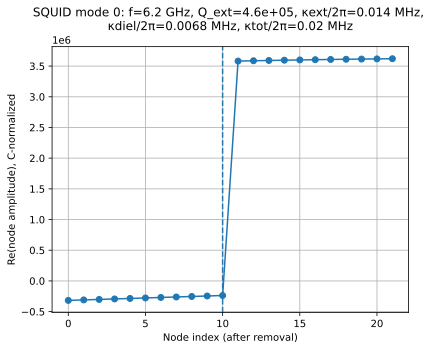

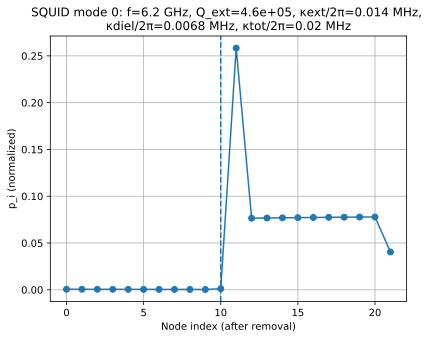

SQUID mode 1: f=19.00,4.16, MHz


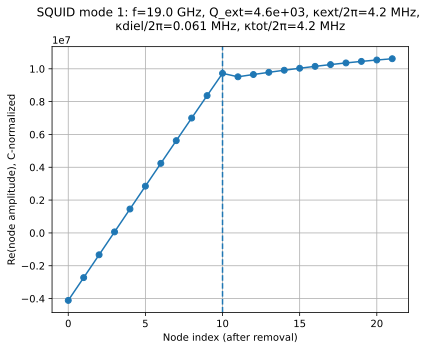

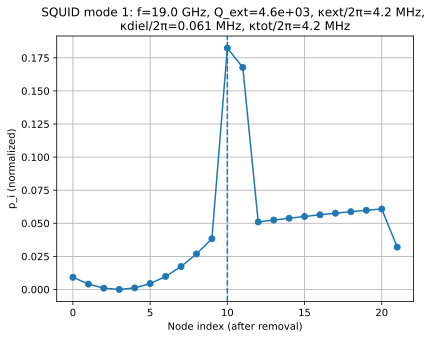

SQUID mode 2: f=33.22,0.0185, MHz


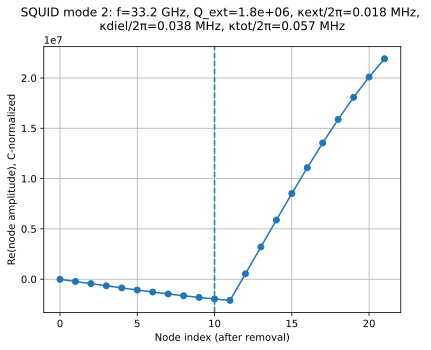

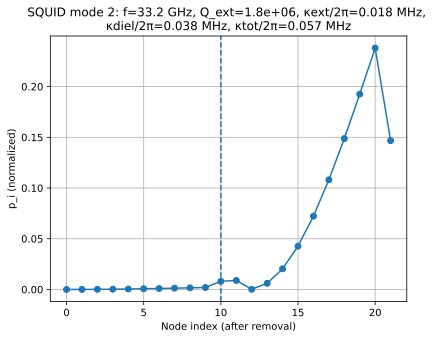

SQUID mode 3: f=38.84,0.000311, MHz


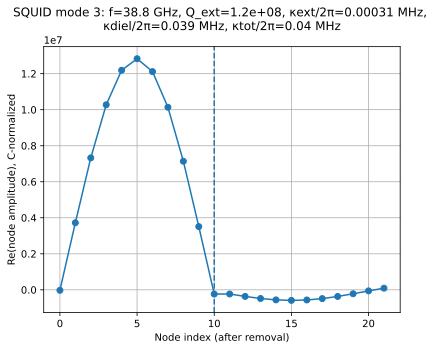

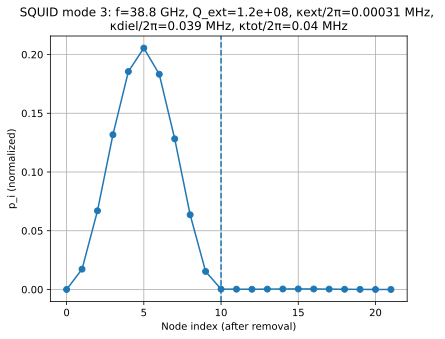

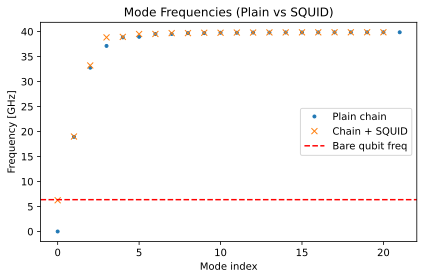

Computing Y_env(f)...


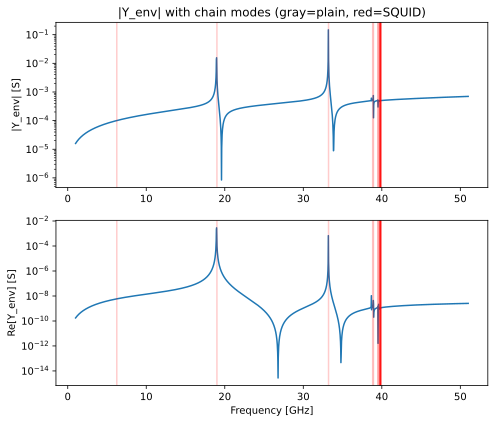

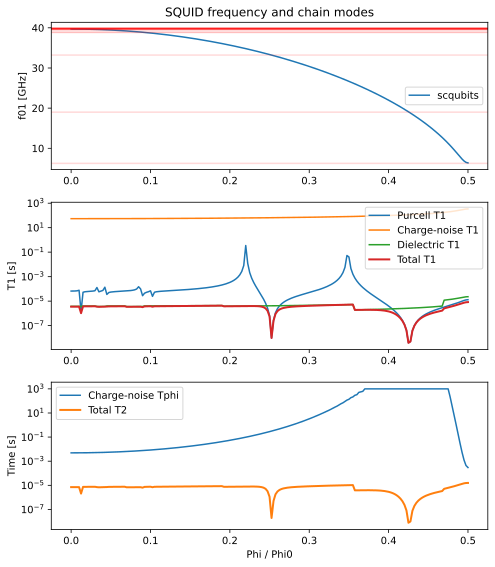

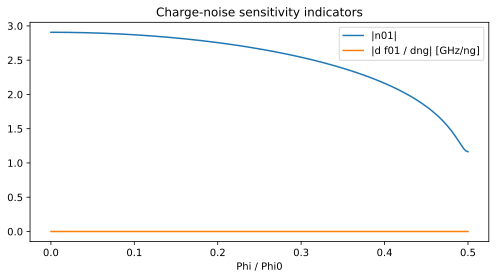

Purcell T1 13.08 , µs at Φ = 0.5 Φ0
Charge-noise Tphi 298.12 , µs at Φ = 0.5 Φ0
Dielectric T1 22.95 , µs at Φ = 0.5 Φ0


In [13]:
import numpy as np
import scipy.constants as const
import matplotlib.pyplot as plt
from numpy.linalg import inv, eig

# ======================================================================
# 0. CONSTANTS
# ======================================================================

h = const.h
e = const.e
pi = np.pi
Phi0 = h / (2 * e)   # flux quantum [Wb]


# ======================================================================
# 1. SQUID + TRANSMON BASICS  (USED FOR PURCELL, NOT FOR MATRIX MODES)
# ======================================================================

def squid_EJ_eff(EJ, d, Phi_ext):
    EJ1 = EJ * (1 + d)
    EJ2 = EJ * (1 - d)
    return np.sqrt(EJ1**2 + EJ2**2 + 2 * EJ1 * EJ2 * np.cos(2*pi*Phi_ext/Phi0))

def squid_LJ(EJ_eff):
    return Phi0**2 / (4 * pi**2 * EJ_eff)

def squid_plasma_freq(EJ_eff, Cq):
    Lj = squid_LJ(EJ_eff)
    return 1.0 / np.sqrt(Lj * Cq)       # [rad/s]


# ======================================================================
# 2. ENVIRONMENT ADMITTANCE (CORRECT NEW MODEL)
# ======================================================================


def Y_feedline(w, Cc, R):
    """
    Kept for compatibility / standalone use.

    Scalar feedline termination seen through a coupling capacitor:
      Z = R + 1/(j w Cc)  ->  Y = 1/Z
    """
    Cc = np.asarray(Cc, dtype=float)
    x = Cc * R * w
    return (Cc**2 * R * w**2 + 1j * Cc * w) / (1 + x**2)


def build_chain_admittance_matrix(N, L_sec, C_sec, Cg, Cc, R, w,
                                  break_middle=True, j_mid=None):
    """
    Admittance model consistent with build_chain_squid / build_chain_plain topology:

      node 0      : feed node
      nodes 1..N+1: chain nodes

    Chain branches:
      (1,2), (2,3), ..., (N,N+1)
      total = N branches

    If break_middle=True, the branch (j_mid, j_mid+1) is removed, so the
    differential admittance seen between those two nodes is the environment
    seen by the SQUID inserted there.

    Cg:
      - scalar: same shunt-to-ground on all chain nodes 1..N+1
      - array: expected to describe the regular chain nodes with the SQUID
               nodes removed; Cg_SQUID1 and Cg_SQUID2 are inserted at
               k = j_mid and k = j_mid+1

    Cc:
      - scalar: same behavior as your matrix builder => one capacitor between
                node 0 and node 1 only
      - array: expected to describe the regular chain nodes with the SQUID
               nodes removed; Cc_SQUID1 and Cc_SQUID2 are inserted at
               k = j_mid and k = j_mid+1

    Returns:
      Y, mid_left, mid_right
    """
    if j_mid is None:
        j_mid = N // 2

    mid_left, mid_right = j_mid, j_mid + 1

    # node 0 = feed, nodes 1..N+1 = chain
    n_nodes = N + 2
    Y = np.zeros((n_nodes, n_nodes), dtype=complex)

    # --------------------------------------------------
    # 1) Chain branches
    # --------------------------------------------------
    Y_sec = 1j * w * C_sec + 1.0 / (1j * w * L_sec)

    for j in range(1, N + 1):
        i1, i2 = j, j + 1

        if break_middle and j == j_mid:
            continue

        if j==j_mid-1:
            Y_sec = 1j * w * C_sec + 1.0 / (1j * w * (L_sec+40e-12))

        Y[i1, i1] += Y_sec
        Y[i2, i2] += Y_sec
        Y[i1, i2] -= Y_sec
        Y[i2, i1] -= Y_sec

        Y_sec = 1j * w * C_sec + 1.0 / (1j * w * L_sec)

    # --------------------------------------------------
    # 2) Shunt Cg to ground on chain nodes
    # --------------------------------------------------
    if np.isscalar(Cg):
        cg = float(Cg)
        Y_shunt = 1j * w * cg
        for k in range(1, N + 2):
            Y[k, k] += Y_shunt

    else:
        Cg_arr = np.asarray(Cg, dtype=float).ravel()

        for k in range(1, N + 2):
            # SQUID split nodes
            if k == mid_left:
                Y[k, k] += 1j * w * Cg_SQUID1
                continue
            elif k == mid_right:
                Y[k, k] += 1j * w * Cg_SQUID2
                continue

            # regular chain nodes, with the two SQUID nodes removed from the array
            if k < mid_left:
                cgk = Cg_arr[k - 1]
            else:  # k > mid_right
                cgk = Cg_arr[k - 3]

            Y[k, k] += 1j * w * cgk

    # --------------------------------------------------
    # 3) Feed coupling capacitors between node 0 and chain nodes
    # --------------------------------------------------
    if np.isscalar(Cc):
        # keep same semantics as build_chain_squid / build_chain_plain:
        # scalar Cc means only one capacitor between node 0 and node 1
        cc = float(Cc)
        ycc = 1j * w * cc

        Y[0, 0] += ycc
        Y[1, 1] += ycc
        Y[0, 1] -= ycc
        Y[1, 0] -= ycc

    else:
        Cc_arr = np.asarray(Cc, dtype=float).ravel()

        for k in range(1, N + 2):
            # SQUID split nodes
            if k == mid_left:
                cck = Cc_SQUID1
            elif k == mid_right:
                cck = Cc_SQUID2
            else:
                # regular chain nodes, with the two SQUID nodes removed from the array
                if k < mid_left:
                    cck = Cc_arr[k - 1]
                else:  # k > mid_right
                    cck = Cc_arr[k - 3]

            ycc = 1j * w * cck

            Y[0, 0] += ycc
            Y[k, k] += ycc
            Y[0, k] -= ycc
            Y[k, 0] -= ycc

    # --------------------------------------------------
    # 4) Feedline resistor to ground on node 0
    # --------------------------------------------------
    Y[0, 0] += 1.0 / R

    return Y, mid_left, mid_right


def Y_env_between_middle_nodes(N, L_sec, C_sec, Cg, Cc, R, w, j_mid=None):
    """
    Differential admittance seen between the two middle nodes where the SQUID sits.
    """
    Ymat, iL, iR = build_chain_admittance_matrix(
        N, L_sec, C_sec, Cg, Cc, R, w,
        break_middle=True, j_mid=j_mid
    )

    n = Ymat.shape[0]
    I = np.zeros(n, dtype=complex)
    I[iL] = 1.0
    I[iR] = -1.0

    V = np.linalg.solve(Ymat, I)
    Zenv = V[iL] - V[iR]
    return 1.0 / Zenv


def Y_env_spectrum(N, L_sec, C_sec, Cg, Cc, R, freqs, j_mid=None):
    out = []
    for f in freqs:
        w = 2 * pi * f
        out.append(Y_env_between_middle_nodes(N, L_sec, C_sec, Cg, Cc, R, w, j_mid=j_mid))
    return np.array(out)


#########################################################################

def make_tunable_transmon(qubit_params, flux, ng=None):
    """
    Helper constructor for scqubits TunableTransmon.
    flux in Weber; internally converted to Phi/Phi0.
    """
    # print(qubit_params)
    return scq.TunableTransmon(
        EJmax=qubit_params['EJ_GHz'],
        EC=qubit_params['EC_GHz'],
        ng=qubit_params['ng'] if ng is None else ng,
        d=qubit_params['d'],
        ncut=qubit_params['ncut'],
        truncated_dim=qubit_params['truncated_dim'],
        flux=flux / Phi0,
    )


def transmon_observables(qubit_params, flux, ng=None):
    """
    Returns:
      w01   [rad/s]
      phi01 [dimensionless, via sin(phi) ~ phi]
      n01   [dimensionless charge matrix element]
      evals [GHz]
      evecs
    """
    qubit = make_tunable_transmon(qubit_params, flux, ng=ng)
    evals, evecs = qubit.eigensys(evals_count=3)

    # 0->1 transition in angular frequency
    w01 = 2 * pi * (evals[1] - evals[0]) * 1e9

    # small-phase proxy
    sinphi = qubit.sin_phi_operator()
    phi01 = (evecs[:, 0].conj().T @ sinphi @ evecs[:, 1]).item()

    # charge operator
    n_op = qubit.n_operator()
    n01 = (evecs[:, 0].conj().T @ n_op @ evecs[:, 1]).item()

    return w01, phi01, n01, evals, evecs


def transmon_charge_dispersion(qubit_params, flux):
    """
    Peak-to-peak 0->1 charge dispersion in [rad/s], estimated from ng = 0 and 0.5.
    This is usually a better measure of charge-noise sensitivity than a local derivative.
    """
    w_ng0, _, _, _, _ = transmon_observables(qubit_params, flux, ng=0.0)
    w_ng05, _, _, _, _ = transmon_observables(qubit_params, flux, ng=0.5)

    delta_omega_01 = np.abs(w_ng0 - w_ng05)
    return delta_omega_01

def EC_Joules_from_params(qubit_params):
    """
    Convert EC from GHz units to Joules.
    """
    return qubit_params['EC_GHz'] * h * 1e9


def gamma_charge_T1_from_Sng(qubit_params, n01, Sng_w01):
    """
    Charge-noise-induced relaxation rate from high-frequency charge-noise PSD.

    Parameters
    ----------
    Sng_w01 : float
        PSD of ng fluctuations at omega01, expressed as a PSD with respect
        to angular frequency omega. Treat as phenomenological input.

    Returns
    -------
    Gamma_1_ng [1/s], T1_ng [s]
    """
    ECJ = EC_Joules_from_params(qubit_params)
    Gamma = ((8 * ECJ) / hbar)**2 * (np.abs(n01)**2) * Sng_w01
    if Gamma <= 0:
        return 0.0, np.inf
    return Gamma, 1.0 / Gamma


def gamma_charge_dephasing_from_dispersion(delta_omega_01, sigma_ng_eff=1.0):
    """
    Charge-noise dephasing estimate from full charge dispersion.

    Parameters
    ----------
    delta_omega_01 : float
        Full 0->1 charge dispersion in rad/s:
            |omega01(ng=0) - omega01(ng=0.5)|

    sigma_ng_eff : float
        Effective fraction of the full dispersion sampled by slow ng fluctuations.
        Use:
          - 1.0 for a rough upper-scale estimate
          - smaller values (e.g. 0.01, 0.1) for a softer phenomenological estimate

    Returns
    -------
    Gamma_phi_ng [1/s], Tphi_ng [s]
    """
    Gamma_phi = np.abs(delta_omega_01) * sigma_ng_eff
    if Gamma_phi <= 0:
        return 0.0, np.inf
    return Gamma_phi, 1.0 / Gamma_phi


def combine_T1_Tphi(T1_purcell=np.inf, Gamma1_extra=0.0, Gamma_phi=0.0):
    """
    Combine Purcell T1 with extra relaxation and dephasing channels.

    Returns:
      Gamma1_tot, T1_tot, Gamma2_tot, T2_tot
    """
    Gamma1_p = 0.0 if not np.isfinite(T1_purcell) else 1.0 / T1_purcell
    Gamma1_tot = Gamma1_p + Gamma1_extra
    T1_tot = np.inf if Gamma1_tot <= 0 else 1.0 / Gamma1_tot

    Gamma2_tot = Gamma1_tot / 2.0 + Gamma_phi
    T2_tot = np.inf if Gamma2_tot <= 0 else 1.0 / Gamma2_tot

    return Gamma1_tot, T1_tot, Gamma2_tot, T2_tot


def Sng_white(S0):
    """
    White charge-noise PSD with respect to angular frequency omega.
    """
    return S0


def Sng_zero():
    """
    No high-frequency charge noise.
    """
    return 0.0



def purcell_gamma_T1(CJ, Cq, Yenv):
    ReY = np.real(Yenv)
    if ReY <= 0:
        return 0.0, np.inf
    Gamma = ReY / (2*CJ+Cq)
    return Gamma, 1/Gamma


def purcell_gamma_T1_qub(omega_q, phi01, Yenv):

    prefactor = hbar / (4 * e**2)  # ~1.0e3 in SI units (Ohms)   

    ReY = np.real(Yenv)
    if ReY <= 0:
        return 0.0, np.inf
    Gamma = prefactor * 2 * omega_q * (np.abs(phi01)**2) * ReY
    return Gamma, 1/Gamma

# ======================================================================
# 4. ORIGINAL MATRIX-CHAIN MODEL (FOR MODE SPECTRA ONLY)
# ======================================================================

def build_chain_plain(
    N,
    LJ,
    CJ,
    Cg,   # scalar OR array-like from HFSS (can be shorter than N)
    Cc,   # scalar OR array-like from HFSS (can be shorter than N)
    R,
):
    """
    Topology (unchanged):
      n = N + 2
        node 0 : strip/port (50Ω environment)
        node 1 : left pad / chain-end node used by LJ/CJ stamps
        nodes 2..N+1 : remaining chain islands

    JJ stamps (UNCHANGED):
      for j=1..N connect (j, j+1) with LJ and CJ.

    Updated only Cg & Cc handling:
      - Cg:
          * scalar: applied to nodes k=2..N+1
          * array-like: interpreted as per-node values for k=2..N+1 (length may be < N)
            If len(Cg_arr) < N, remaining nodes get 0.
      - Cc:
          * scalar: same capacitor value between node 0 and each node k=2..N+1
          * array-like: distributed coupling caps between node 0 and node k=2..N+1 (length may be < N)
            If len(Cc_arr) < N, remaining nodes get 0.

    Note: We do NOT use HFSS diagonals; we only stamp the selected mutuals (as caps).
    """
    n = N + 2
    K = np.zeros((n, n), dtype=float)
    C = np.zeros((n, n), dtype=float)
    G = np.zeros((n, n), dtype=float)

    # -----------------------------
    # JJ inductors & capacitors (UNCHANGED)
    # -----------------------------
    valL = 1.0 / LJ
    for j in range(1, N + 1):
        i1, i2 = j, j + 1
        K[i1, i1] += valL; K[i2, i2] += valL
        K[i1, i2] -= valL; K[i2, i1] -= valL

        C[i1, i1] += CJ;  C[i2, i2] += CJ
        C[i1, i2] -= CJ;  C[i2, i1] -= CJ

    # -----------------------------
    # Helper: fetch per-island value with zero-padding
    # -----------------------------
    def _as_array_or_none(x):
        return None if np.isscalar(x) else np.asarray(x, dtype=float).ravel()

    Cg_arr = _as_array_or_none(Cg)
    Cc_arr = _as_array_or_none(Cc)

    # -----------------------------
    # Shunt Cg on nodes k=2..N+1
    # -----------------------------
    if Cg_arr is None:
        cg = float(Cg)
        if cg != 0.0 or True:  # even if cg=0, we can still add it without harm; this simplifies the logic and avoids missing any nonzero entries due to a strict check
            for k in range(1, N + 2):
                C[k, k] += cg
    else:
        n_hfss = int(Cg_arr.size)
        # if shorter, missing nodes are treated as 0 automatically
        for idx, k in enumerate(range(1, N + 2)):  # idx=0..N-1
            if idx < n_hfss:
                cg = Cg_arr[idx]
                if cg != 0.0 or True:  # even if cg=0, we can still add it without harm; this simplifies the logic and avoids missing any nonzero entries due to a strict check
                    C[k, k] += cg
            # else: cg=0, do nothing

    # -----------------------------
    # Port coupling Cc between node 0 and nodes k=2..N+1
    # -----------------------------
    if Cc_arr is None:
        cc = float(Cc)
        if cc != 0.0 or True:  # even if cc=0, we can still add it without harm; this simplifies the logic and avoids missing any nonzero entries due to a strict check
            # for k in range(2, N + 2):
            C[0, 0] += cc
            C[1, 1] += cc
            C[0, 1] -= cc
            C[1, 0] -= cc
    else:
        n_hfss = int(Cc_arr.size)
        for idx, k in enumerate(range(1, N + 2)):  # idx=0..N-1
            if idx < n_hfss:
                cc = Cc_arr[idx]
                if cc != 0.0 or True:  # even if cc=0, we can still add it without harm; this simplifies the logic and avoids missing any nonzero entries due to a strict check
                    C[0, 0] += cc
                    C[k, k] += cc
                    C[0, k] -= cc
                    C[k, 0] -= cc
            # else: cc=0, do nothing
                # print(idx, k, cc/fF_to_F)

    # -----------------------------
    # Dissipation at port node
    # -----------------------------
    G[0, 0] = 1.0 / R

    return K, C, G


def build_chain_squid(N, LJ, CJ, Cg, Cc, R, qubit_params, Phi_ext, N_SQ=None):
    if N_SQ is None:
        N_SQ = N // 2

    w01, _,_,_,_ = transmon_observables(qubit_params, Phi_ext)

    CJ_s =qubit_params['CJ'] # total capacitance of the SQUID (two junctions in parallel)
    LJ_s = 1.0 / (w01**2 * CJ_s)

    n = N + 2
    K = np.zeros((n, n), dtype=float)
    C = np.zeros((n, n), dtype=float)
    G = np.zeros((n, n), dtype=float)

    # --------------------------------------------------
    # Inductors & capacitors, with one junction replaced by SQUID
    # (UNCHANGED logic for LJ/CJ vs LJ_s/CJ_s)
    # --------------------------------------------------
    for j in range(1, N + 1):
        # if j<N:    
        i1, i2 = j, j + 1

        if j == N_SQ:
            valL = 1.0 / LJ_s
            CJ_eff = CJ_s
        else:
            valL = 1.0 / LJ
            CJ_eff = CJ

        K[i1, i1] += valL; K[i2, i2] += valL
        K[i1, i2] -= valL; K[i2, i1] -= valL

        C[i1, i1] += CJ_eff; C[i2, i2] += CJ_eff
        C[i1, i2] -= CJ_eff; C[i2, i1] -= CJ_eff
    #     else:
    #         # Last junction replaced by a large island
    #         i1, i2 = N, N+1
            
    #         C_last_to_prelast = 0.16e-15
    #         CJ_eff = C_last_to_prelast

    #         C[i1, i1] += CJ_eff; C[i2, i2] += CJ_eff
    #         C[i1, i2] -= CJ_eff; C[i2, i1] -= CJ_eff

    # # last node to feed (large pad capacitance)
    # C_last_to_gnd = 9.17e-15
    # C[N+1, N+1] += C_last_to_gnd
    # C[0, 0] += C_last_to_gnd
    # C[0, N+1] -= C_last_to_gnd
    # C[N+1, 0] -= C_last_to_gnd

    # # last node to other nodes (stray capacitances)
    # C_last_to_others = 0.05e-15
    # for k in range(2, N + 1):
    #     C[k, k] += C_last_to_others
    #     C[k, N+1] -= C_last_to_others
    #     C[N+1, k] -= C_last_to_others
    #     C[N+1, N+1] += C_last_to_others

    # # last node to 1st island (stray capacitance)
    # C_last_to_first = 0.58e-15
    # C[1, 1] += C_last_to_first
    # C[1, N+1] -= C_last_to_first
    # C[N+1, 1] -= C_last_to_first
    # C[N+1, N+1] += C_last_to_first

    # --------------------------------------------------
    # UPDATED Cg handling (scalar OR array-like, can be shorter than N)
    # Applies to nodes k = 2..N+1 (N nodes)
    # Missing entries (if HFSS shorter) => treated as 0
    # --------------------------------------------------
    if np.isscalar(Cg):
        cg = float(Cg)
        if cg != 0.0 or True:  # even if cg=0, we can still add it without harm; this simplifies the logic and avoids missing any nonzero entries due to a strict check
            for k in range(1, N + 2):
                C[k, k] += cg
    else:
        Cg_arr = np.asarray(Cg, dtype=float).ravel()
        n_hfss = int(Cg_arr.size)
        for idx, k in enumerate(range(1, N + 2)):  # idx=0..N-1
            # if idx < n_hfss:
            if k == N_SQ:
                # print(f"Stamping Cg_SQUID={Cg_SQUID1} F at node {k}")
                C[k, k] += Cg_SQUID1
                continue
            elif k == N_SQ + 1:
                # print(f"Stamping Cg_SQUID={Cg_SQUID2} F at node {k}")
                C[k, k] += Cg_SQUID2
                continue
            
            cg = None
            if k > N_SQ + 1:
                cg = Cg_arr[idx-2]  # shift by 2 to account for the two middle nodes reserved for the qubit
            else:
                cg = Cg_arr[idx]


            if cg != 0.0 or True:  # even if cg=0, we can still add it without harm; this simplifies the logic and avoids missing any nonzero entries due to a strict check
                C[k, k] += cg
            # else: cg=0 -> do nothing

    # --------------------------------------------------
    # UPDATED Cc handling (scalar OR array-like, can be shorter than N)
    # Now: distributed coupling caps between port node 0 and nodes k = 2..N+1
    # Missing entries (if HFSS shorter) => treated as 0
    # --------------------------------------------------
    if np.isscalar(Cc):
        cc = float(Cc)
        if cc != 0.0 or True:  # even if cc=0, we can still add it without harm; this simplifies the logic and avoids missing any nonzero entries due to a strict check
            # for k in range(2, N + 2):
            C[0, 0] += cc
            C[1, 1] += cc
            C[0, 1] -= cc
            C[1, 0] -= cc
    else:
        Cc_arr = np.asarray(Cc, dtype=float).ravel()
        n_hfss = int(Cc_arr.size)
        for idx, k in enumerate(range(1, N + 2)):  # idx=0..N-1
            if k == N_SQ:
                # print(f"Stamping Cc_SQUID={Cc_SQUID1} F at node {k}")
                C[0, 0] += Cc_SQUID1
                C[k, k] += Cc_SQUID1
                C[0, k] -= Cc_SQUID1
                C[k, 0] -= Cc_SQUID1
                continue
            elif k == N_SQ + 1:
                # print(f"Stamping Cc_SQUID={Cc_SQUID2} F at node {k}")
                C[0, 0] += Cc_SQUID2
                C[k, k] += Cc_SQUID2
                C[0, k] -= Cc_SQUID2
                C[k, 0] -= Cc_SQUID2
                continue


            cc = None
            # if idx < n_hfss:
            if k > N_SQ + 1:
                cc = Cc_arr[idx-2]  # shift by 2 to account for the two middle nodes reserved for the qubit
            else:
                cc = Cc_arr[idx]
            if cc != 0.0 or True:  # even if cc=0, we can still add it without harm; this simplifies the logic and avoids missing any nonzero entries due to a strict check
                C[0, 0] += cc
                C[k, k] += cc
                C[0, k] -= cc
                C[k, 0] -= cc
            # else: cc=0 -> do nothing

            # print(idx, k, cc/fF_to_F)

    # --------------------------------------------------
    # Dissipation at port node
    # --------------------------------------------------
    G[0, 0] = 1.0 / R

    return K, C, G, LJ_s, CJ_s, N_SQ



def s21(K,C,G,R,freqs):
    n = C.shape[0]
    S = []
    b = np.zeros(n); b[0]=1/R
    for f in freqs:
        w = 2*np.pi*f
        M = K - w*w*C + 1j*w*G
        phi = np.linalg.solve(M,b)
        S.append(phi[-1])
    return np.array(S)

def s21_lossy(K, C, G, R, freqs, kappa_i=0, gamma_i=0):
    """
    Adds internal losses to:
        node 1 = resonator:  kappa_i
        node 2 = qubit:      gamma_i
    """

    n = C.shape[0]
    S_phi0 = []
    S_phi1 = []
    S_phi2 = []

    for f in freqs:
        w = 2*np.pi*f

        # copy G each iteration (never modify input)
        G_eff = G.copy()

        # Add internal loss conductances:
        # physically, G has units of siemens (Ohm^-1)
        # damping term is (i*ω)*G in the equations.
        G_eff[1,1] += kappa_i / w       # resonator intrinsic loss
        G_eff[N//2,N//2] += gamma_i / w       # qubit intrinsic loss

        # Standard solve
        b = np.zeros(n)
        b[0] = 1/R

        M = K - w*w*C + 1j*w*G_eff
        phi = np.linalg.solve(M, b)
        S_phi0.append(phi[0])  # measure at port node
        S_phi1.append(phi[1])  # measure at resonator node
        S_phi2.append(phi[N//2])  # measure at resonator node (or phi[-1] if you want qubit node)

    return np.array(S_phi0), np.array(S_phi1), np.array(S_phi2)


def build_A(K,C,G):
    n = C.shape[0]
    Cinv = inv(C)
    zero = np.zeros((n,n))
    I = np.eye(n)
    A = np.block([[zero, I], [-Cinv@K, -Cinv@G]])
    return A

def compute_modes(A):
    lam, vec = eig(A)
    mask = np.imag(lam) > 0
    lam = lam[mask]
    vec = vec[:,mask]
    order = np.argsort(np.imag(lam))
    lam = lam[order]
    vec = vec[:,order]

    omega = np.imag(lam)
    freqs = omega/(2*pi)
    Q = omega / (2*(-np.real(lam)))
    return freqs, Q, lam, vec


def compare_modes(freqs_plain, freqs_squid, f_q):
    plt.figure(figsize=(6,4))
    plt.plot(freqs_plain/1e9, '.', label='Plain chain')
    plt.plot(freqs_squid/1e9, 'x', label='Chain + SQUID')
    plt.axhline(f_q/1e9, color='r', linestyle='--', label='Bare qubit freq')
    plt.xlabel("Mode index")
    plt.ylabel("Frequency [GHz]")
    plt.legend()
    plt.title("Mode Frequencies (Plain vs SQUID)")
    plt.tight_layout()
    plt.show()


# ======================================================================
# 4.5 DIELECTRIC PARTICIPATION + Q_diel + T1_diel
# ======================================================================
def _extract_node_block_from_state_evecs(evecs, n_nodes, which="first"):
    V = np.array(evecs, dtype=complex)
    if V.shape[0] == n_nodes:
        return V
    if V.shape[0] == 2 * n_nodes:
        return V[:n_nodes, :] if which == "first" else V[-n_nodes:, :]
    raise ValueError(f"Unexpected evecs shape {V.shape}; expected {n_nodes} or {2*n_nodes} rows.")

#############################
# MODE ANALYSIS
#############################
# ============================================================
# DROP-IN: add kappa (and kappa/2pi in MHz) to the mode-shape plots
# Works with your existing freq[], Q[] arrays (from compute_modes).
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

def _C_normalize_modes(V_nodes, C_nodes):
    V = np.array(V_nodes, dtype=complex, copy=True)
    for k in range(V.shape[1]):
        vk = V[:, k]
        nk = np.sqrt(np.abs(vk.conj().T @ (C_nodes @ vk)))
        if nk > 0:
            V[:, k] = vk / nk
    return V

def _mode_participation(v, C):
    Cdiag = np.real(np.diag(C))
    p = (np.abs(v)**2) * np.maximum(Cdiag, 0.0)
    s = p.sum()
    return p / s if s > 0 else p

def analyze_and_plot_modes(tag, C, freq, Q, evecs, idx_squid=None,
                           n_show=6, remove_nodes=(0,), start_mode=0,
                           state_node_block="first"):
    """
    Adds kappa on plot titles:
      kappa = omega / Q  (rad/s)
      kappa/2pi = f / Q  (Hz)
    Uses freq in Hz (as returned by your compute_modes).
    """
    global MODE_IDX, FREQ1, FREQ2, KAPPA

    n = C.shape[0]

    # Extract node-component eigenvectors if evecs are for state-space A
    Vnodes_full = _extract_node_block_from_state_evecs(evecs, n_nodes=n, which=state_node_block)

    keep = np.ones(n, dtype=bool)
    for rn in remove_nodes:
        if 0 <= rn < n:
            keep[rn] = False

    Ck = C[np.ix_(keep, keep)]
    Vk = Vnodes_full[keep, :]
    Vk = _C_normalize_modes(Vk, Ck)

    nodes_kept = np.where(keep)[0]
    mode_ids = list(range(start_mode, min(start_mode + n_show, Vk.shape[1])))

    squid_plot_idx = None
    if idx_squid is not None and 0 <= idx_squid < n and keep[idx_squid]:
        squid_plot_idx = np.where(nodes_kept == idx_squid)[0][0]

    for m in mode_ids:
        v = Vk[:, m]

        # Choose a consistent global phase for pretty plots
        imax = np.argmax(np.abs(v))
        phase = np.exp(-1j * np.angle(v[imax])) if np.abs(v[imax]) > 0 else 1.0
        v = v * phase

        v_plot = np.real(v)
        p = _mode_participation(v, Ck)

        f_Hz = float(freq[m]) if np.isfinite(freq[m]) else np.nan
        Qm = float(Q[m]) if np.isfinite(Q[m]) else np.nan

        # kappa from Q and freq (no need for evals):
        # kappa/2pi (Hz) = f / Q
        # kappa (rad/s) = 2pi f / Q
        if np.isfinite(f_Hz) and np.isfinite(Qm) and Qm > 0:
            kappa_over_2pi_Hz = f_Hz / Qm
            kappa_over_2pi_MHz = kappa_over_2pi_Hz / 1e6
        else:
            kappa_over_2pi_MHz = np.nan



                # dielectric contribution for this mode if available
        if tag == "SQUID" and m < len(diel_summary_squid):
            Q_diel_m = diel_summary_squid[m]["Q_diel"]
            kappa_diel_over_2pi_MHz = diel_summary_squid[m]["kappa_diel_over_2pi_Hz"] / 1e6

            if np.isfinite(Q_diel_m) and Q_diel_m > 0 and np.isfinite(Qm) and Qm > 0:
                # Qm from eigenvalues is your current external / loaded value from G=1/R only
                # combine linewidths, not Qs, because kappas add
                kappa_ext_over_2pi_Hz = f_Hz / Qm
                kappa_tot_over_2pi_MHz = (kappa_ext_over_2pi_Hz + diel_summary_squid[m]["kappa_diel_over_2pi_Hz"]) / 1e6
            else:
                kappa_diel_over_2pi_MHz = np.nan
                kappa_tot_over_2pi_MHz = np.nan
        else:
            kappa_diel_over_2pi_MHz = np.nan
            kappa_tot_over_2pi_MHz = np.nan




        fGHz = f_Hz / 1e9 if np.isfinite(f_Hz) else np.nan

        print(f"{tag} mode {m}: f={fGHz:.2f},{kappa_over_2pi_MHz:.3g}, MHz")

        if m==0 and (fGHz < 0.5):
            MODE_IDX += 1
            print(f"  Warning: mode {m} has out-of-range frequency {fGHz:.2f} GHz; check if it's a physical mode or a numerical artifact.")

        elif m == MODE_IDX:
            FREQ1 = fGHz
            KAPPA = kappa_over_2pi_MHz
        elif m == MODE_IDX+1:
            FREQ2 = fGHz

        # --- Mode shape plot ---
        plt.figure()
        plt.plot(v_plot, marker="o")
        if squid_plot_idx is not None:
            plt.axvline(squid_plot_idx, linestyle="--")
        plt.title(
            f"{tag} mode {m}: f={fGHz:.1f} GHz, "
            f"Q_ext={Qm:.2g}, "
            f"κext/2π={kappa_over_2pi_MHz:.2g} MHz, "
            "\n"
            f"κdiel/2π={kappa_diel_over_2pi_MHz:.2g} MHz, "
            f"κtot/2π={kappa_tot_over_2pi_MHz:.2g} MHz"
        )
        plt.xlabel("Node index (after removal)")
        plt.ylabel("Re(node amplitude), C-normalized")
        plt.grid(True)
        plt.show()

        # --- Participation plot ---
        plt.figure()
        plt.plot(p, marker="o")
        if squid_plot_idx is not None:
            plt.axvline(squid_plot_idx, linestyle="--")
        plt.title(
            f"{tag} mode {m}: f={fGHz:.1f} GHz, "
            f"Q_ext={Qm:.2g}, "
            f"κext/2π={kappa_over_2pi_MHz:.2g} MHz, "
            "\n"
            f"κdiel/2π={kappa_diel_over_2pi_MHz:.2g} MHz, "
            f"κtot/2π={kappa_tot_over_2pi_MHz:.2g} MHz"
        )
        plt.xlabel("Node index (after removal)")
        plt.ylabel("p_i (normalized)")
        plt.grid(True)
        plt.show()


def _extract_node_evecs_for_modes(Cmat, evecs, remove_feed=True, state_node_block="first"):
    """
    Returns node eigenvectors (columns = modes) in the physical node basis.
    Compatible with the state-space eigenvectors returned by compute_modes/build_A.
    """
    n = Cmat.shape[0]
    Vnodes_full = _extract_node_block_from_state_evecs(evecs, n_nodes=n, which=state_node_block)

    if remove_feed:
        keep = np.ones(n, dtype=bool)
        keep[0] = False
        Ck = Cmat[np.ix_(keep, keep)]
        Vk = Vnodes_full[keep, :]
        node_labels = np.arange(1, n)
    else:
        Ck = Cmat
        Vk = Vnodes_full
        node_labels = np.arange(n)

    Vk = _C_normalize_modes(Vk, Ck)
    return Ck, Vk, node_labels


def _regular_chain_caps_with_squid_nodes(N, arr_regular, N_SQ, val_sq_left, val_sq_right):
    """
    Build a full length-(N+1) array for chain nodes 1..N+1, inserting the two SQUID-node values
    at N_SQ and N_SQ+1, while arr_regular contains all the OTHER chain-node values.
    """
    out = np.zeros(N + 1, dtype=float)
    arr_regular = np.asarray(arr_regular, dtype=float).ravel()

    ptr = 0
    for k in range(1, N + 2):
        if k == N_SQ:
            out[k - 1] = val_sq_left
        elif k == N_SQ + 1:
            out[k - 1] = val_sq_right
        else:
            if ptr < len(arr_regular):
                out[k - 1] = arr_regular[ptr]
                ptr += 1
            else:
                out[k - 1] = 0.0
    return out


def mode_dielectric_participations(v_nodes, N, CJ, Cg_arr_full, CJ_s, N_SQ):
    """
    v_nodes: node-mode vector WITHOUT feed node, ordered as physical chain nodes 1..N+1.
             length = N+1

    Returns electric-energy participations:
      p_Cg       : silicon / shunt-ground participation
      p_CJ_reg   : regular JJ dielectric participation
      p_CJ_sq    : SQUID junction dielectric participation
      p_tot      : should be ~1 for the purely electric partition used here
    """
    v = np.asarray(v_nodes, dtype=complex)
    assert v.shape[0] == N + 1

    # Shunt-to-ground electric energy
    U_Cg = np.sum(Cg_arr_full * np.abs(v)**2)

    # Junction-capacitor electric energy on regular branches
    U_CJ_reg = 0.0
    U_CJ_sq = 0.0

    for j in range(1, N + 1):
        dv2 = np.abs(v[j - 1] - v[j])**2
        if j == N_SQ:
            U_CJ_sq += CJ_s * dv2
        else:
            U_CJ_reg += CJ * dv2

    U_E = U_Cg + U_CJ_reg + U_CJ_sq

    if U_E <= 0:
        return {
            "p_Cg": 0.0,
            "p_CJ_reg": 0.0,
            "p_CJ_sq": 0.0,
            "p_tot": 0.0,
            "U_Cg": 0.0,
            "U_CJ_reg": 0.0,
            "U_CJ_sq": 0.0,
            "U_E": 0.0,
        }

    return {
        "p_Cg": U_Cg / U_E,
        "p_CJ_reg": U_CJ_reg / U_E,
        "p_CJ_sq": U_CJ_sq / U_E,
        "p_tot": (U_Cg + U_CJ_reg + U_CJ_sq) / U_E,
        "U_Cg": U_Cg,
        "U_CJ_reg": U_CJ_reg,
        "U_CJ_sq": U_CJ_sq,
        "U_E": U_E,
    }


def dielectric_Q_from_participation(parts, tan_delta_Si, tan_delta_JJ, tan_delta_SQUID=None):
    """
    Compute Q_diel from participations and loss tangents.
    """
    if tan_delta_SQUID is None:
        tan_delta_SQUID = tan_delta_JJ

    invQ = (
        parts["p_Cg"] * tan_delta_Si
        + parts["p_CJ_reg"] * tan_delta_JJ
        + parts["p_CJ_sq"] * tan_delta_SQUID
    )

    if invQ <= 0:
        return np.inf
    return 1.0 / invQ


def dielectric_kappa_from_Q(freq_Hz, Q_diel):
    """
    Returns kappa_diel in rad/s and kappa_diel/2pi in Hz.
    """
    if not np.isfinite(Q_diel) or Q_diel <= 0:
        return 0.0, 0.0
    kappa_over_2pi = freq_Hz / Q_diel
    kappa = 2 * pi * kappa_over_2pi
    return kappa, kappa_over_2pi


def dielectric_mode_summary(N, Cmat, evecs, freqs, CJ, Cg_array, CJ_s, N_SQ,
                            tan_delta_Si, tan_delta_JJ, tan_delta_SQUID=None,
                            state_node_block="first"):
    """
    Compute dielectric participations and Q_diel for all modes.
    """
    Ck, Vk, node_labels = _extract_node_evecs_for_modes(
        Cmat, evecs, remove_feed=True, state_node_block=state_node_block
    )

    # Build full chain-node Cg array including the two SQUID nodes
    Cg_full = _regular_chain_caps_with_squid_nodes(
        N, Cg_array, N_SQ, Cg_SQUID1, Cg_SQUID2
    )

    out = []
    for m in range(Vk.shape[1]):
        v = Vk[:, m]   # length N+1, nodes 1..N+1
        parts = mode_dielectric_participations(v, N, CJ, Cg_full, CJ_s, N_SQ)
        Q_diel = dielectric_Q_from_participation(
            parts, tan_delta_Si, tan_delta_JJ, tan_delta_SQUID=tan_delta_SQUID
        )
        kappa_diel, kappa_diel_over_2pi = dielectric_kappa_from_Q(freqs[m], Q_diel)

        out.append({
            "mode": m,
            "freq_Hz": freqs[m],
            "Q_diel": Q_diel,
            "kappa_diel": kappa_diel,
            "kappa_diel_over_2pi_Hz": kappa_diel_over_2pi,
            **parts
        })
    return out


def T1_dielectric_from_Q_and_freq(freq_Hz, Q_diel):
    """
    For a dielectric-limited oscillator-like loss channel:
        T1 = Q / omega
    """
    if not np.isfinite(Q_diel) or Q_diel <= 0 or freq_Hz <= 0:
        return np.inf
    omega = 2 * pi * freq_Hz
    return Q_diel / omega

def dielectric_gamma_T1_from_Q(freq_Hz, Q_diel):
    """
    Gamma = omega / Q_diel
    """
    if not np.isfinite(Q_diel) or Q_diel <= 0 or freq_Hz <= 0:
        return 0.0, np.inf
    omega = 2 * pi * freq_Hz
    Gamma = omega / Q_diel
    return Gamma, 1.0 / Gamma


# ======================================================================
# 5. MAIN SCRIPT (INTEGRATED)
# ======================================================================


# Flux sweep
Phi_list = np.linspace(0, 0.5*Phi0, 201)



# ======================================================================
# FULL-C HFSS-AWARE BUILDERS
# ======================================================================
# These override the old builders while keeping their call signatures.
# If USE_FULL_HFSS_C=True and C_HFSS exists, the solver starts from the
# complete reduced Maxwell capacitance matrix and only stamps the JJ
# capacitances/inductances. It does NOT restamp Cg_array/Cc_array.
#
# If USE_FULL_HFSS_C=False, these functions fall back to the legacy builders.

_build_chain_plain_legacy = build_chain_plain
_build_chain_squid_legacy = build_chain_squid
_build_chain_admittance_matrix_legacy = build_chain_admittance_matrix


def _full_hfss_active():
    return bool(globals().get("USE_FULL_HFSS_C", False)) and globals().get("C_HFSS", None) is not None


def _stamp_branch(K, C, i1, i2, L_branch, C_branch):
    """Stamp an inductor and a branch capacitance between two nodal variables."""
    valL = 1.0 / L_branch
    K[i1, i1] += valL
    K[i2, i2] += valL
    K[i1, i2] -= valL
    K[i2, i1] -= valL

    if C_branch is not None and C_branch != 0.0:
        C[i1, i1] += C_branch
        C[i2, i2] += C_branch
        C[i1, i2] -= C_branch
        C[i2, i1] -= C_branch


def _stamp_admittance_branch(Y, i1, i2, y_branch):
    Y[i1, i1] += y_branch
    Y[i2, i2] += y_branch
    Y[i1, i2] -= y_branch
    Y[i2, i1] -= y_branch


def _check_hfss_shape_or_raise(N):
    C0 = np.asarray(globals()["C_HFSS"], dtype=float)
    expected = N + 2  # feed + N+1 chain nodes
    if C0.shape != (expected, expected):
        raise ValueError(
            f"C_HFSS shape {C0.shape} is inconsistent with N={N}. "
            f"Expected {(expected, expected)}. "
            "Re-run the HFSS import cell so N is inferred from the matrix."
        )
    return C0


def build_chain_plain(N, LJ, CJ, Cg, Cc, R):
    """
    HFSS-full-C version of the plain chain builder.

    When USE_FULL_HFSS_C=True:
      C = full reduced Maxwell C from file + regular JJ capacitances.
      K = regular JJ inductors along the inferred node order.
      G = 50 Ohm feedline conductance on node 0.
    """
    if not _full_hfss_active():
        return _build_chain_plain_legacy(N, LJ, CJ, Cg, Cc, R)

    C = _check_hfss_shape_or_raise(N).copy()
    n = C.shape[0]
    K = np.zeros((n, n), dtype=float)
    G = np.zeros((n, n), dtype=float)

    # Branch j connects circuit nodes j and j+1.
    # node 0 is feed, nodes 1..N+1 are the ordered physical chain/SQUID nodes.
    for j in range(1, N + 1):
        _stamp_branch(K, C, j, j + 1, LJ, CJ)

    G[0, 0] = 1.0 / R
    return K, C, G


def build_chain_squid(N, LJ, CJ, Cg, Cc, R, qubit_params, Phi_ext, N_SQ=None):
    """
    HFSS-full-C version of the chain+SQUID builder.

    The SQUID is the branch between node N_SQ and node N_SQ+1.
    With the new importer, N_SQ is inferred from SQUID_lid1/SQUID_lid2
    whenever those conductors are present in the HFSS matrix.
    """
    if not _full_hfss_active():
        return _build_chain_squid_legacy(N, LJ, CJ, Cg, Cc, R, qubit_params, Phi_ext, N_SQ=N_SQ)

    if N_SQ is None:
        N_SQ = globals().get("N_SQUID", N // 2)

    C = _check_hfss_shape_or_raise(N).copy()
    n = C.shape[0]
    K = np.zeros((n, n), dtype=float)
    G = np.zeros((n, n), dtype=float)

    w01, _, _, _, _ = transmon_observables(qubit_params, Phi_ext)

    CJ_s = qubit_params["CJ"]          # total SQUID junction capacitance
    LJ_s = 1.0 / (w01**2 * CJ_s)

    for j in range(1, N + 1):
        if j == N_SQ:
            _stamp_branch(K, C, j, j + 1, LJ_s, CJ_s)
        else:
            _stamp_branch(K, C, j, j + 1, LJ, CJ)

    G[0, 0] = 1.0 / R
    return K, C, G, LJ_s, CJ_s, N_SQ


def build_chain_admittance_matrix(N, L_sec, C_sec, Cg, Cc, R, w,
                                  break_middle=True, j_mid=None):
    """
    HFSS-full-C version of the admittance matrix.

    For USE_FULL_HFSS_C=True:
      Y = G + j*w*C_HFSS + regular branch admittances.
    The SQUID/middle branch is omitted when break_middle=True, so
    Y_env_between_middle_nodes probes the environment seen by the SQUID.
    """
    if not _full_hfss_active():
        return _build_chain_admittance_matrix_legacy(
            N, L_sec, C_sec, Cg, Cc, R, w,
            break_middle=break_middle, j_mid=j_mid
        )

    if j_mid is None:
        j_mid = globals().get("N_SQUID", N // 2)

    C0 = _check_hfss_shape_or_raise(N)
    n = C0.shape[0]

    Y = 1j * w * C0.astype(complex)
    Y[0, 0] += 1.0 / R

    for j in range(1, N + 1):
        if break_middle and j == j_mid:
            continue

        # Optional tiny geometric inductance correction preserved from old code.
        L_here = L_sec + 40e-12 if j == j_mid - 1 else L_sec
        y_branch = 1.0 / (1j * w * L_here) + 1j * w * C_sec
        _stamp_admittance_branch(Y, j, j + 1, y_branch)

    return Y, j_mid, j_mid + 1



# Frequency span for Y_env
f_span = np.linspace(1e9, 51e9, 2000)


# ======================================================================
# 5.1 COMPUTE MATRIX MODES (REFERENCE FOR PLOTS)
# ======================================================================

print("Computing matrix-chain modes (plain)...")
# Kp,Cp,Gp = build_chain_plain(N, LJ, CJ, Cg, Cc, R)
Kp,Cp,Gp = build_chain_plain(N, LJ, CJ, Cg_array, Cc_array, R)
Ap = build_A(Kp,Cp,Gp)
freq_plain, Q_plain, evals_plain, evecs_plain = compute_modes(Ap)

print("Computing matrix-chain modes (with SQUID)...")
Ks,Cs,Gs, LJ_s, CJ_s, idx_squid = build_chain_squid(
    N, LJ, CJ, Cg_array, Cc_array, R, qubit_params, Phi_list[-1], N_SQ=N_SQUID
)
As = build_A(Ks,Cs,Gs)
freq_squid, Q_squid, evals_squid, evecs_squid = compute_modes(As)


# ======================================================================
# 5.1b DIELECTRIC MODE LOSS SUMMARY
# ======================================================================

diel_summary_squid = dielectric_mode_summary(
    N=N,
    Cmat=Cs,
    evecs=evecs_squid,
    freqs=freq_squid,
    CJ=CJ,
    Cg_array=Cg_array,
    CJ_s=CJ_s,
    N_SQ=N_SQUID,
    tan_delta_Si=tan_delta_Si,
    tan_delta_JJ=tan_delta_JJ,
    tan_delta_SQUID=tan_delta_SQUID,
    state_node_block="first",
)

for row in diel_summary_squid[:6]:
    print(
        f"mode {row['mode']}: "
        f"f={row['freq_Hz']/1e9:.3f} GHz, "
        f"Q_diel={row['Q_diel']:.3g}, "
        f"kappa_diel/2pi={row['kappa_diel_over_2pi_Hz']/1e6:.3g} MHz, "
        f"p_Cg={row['p_Cg']:.3f}, "
        f"p_CJ_reg={row['p_CJ_reg']:.3f}, "
        f"p_CJ_sq={row['p_CJ_sq']:.3f}"
    )





# =======================
# Use it (drop-in)
# =======================
# analyze_and_plot_modes(
#     tag="PLAIN",
#     C=Cp,
#     freq=freq_plain, Q=Q_plain,
#     evecs=evecs_plain,
#     idx_squid=None,
#     n_show=6,
#     remove_nodes=(0,),
#     start_mode=0,
#     state_node_block="first"   # if shapes look wrong, switch to "last"
# )

analyze_and_plot_modes(
    tag="SQUID",
    C=Cs,
    freq=freq_squid, Q=Q_squid,
    evecs=evecs_squid,
    idx_squid=idx_squid,
    n_show=4,
    remove_nodes=(0,),
    start_mode=0,
    state_node_block="first"   # if shapes look wrong, switch to "last"
)
# np.save("modes_plain.npy", evals_plain)
# np.save("modes_squid.npy", evals_squid)



w01, phi01, n01, evals_q, evecs_q = transmon_observables(qubit_params, 0.5*Phi0)
compare_modes(freq_plain, freq_squid, w01/(2*pi))

# ======================================================================
# 5.2 ENVIRONMENT ADMITTANCE SPECTRUM
# ======================================================================

print("Computing Y_env(f)...")
try:
    Y_env = Y_env_spectrum(N, LJ, CJ, Cg_array, Cc_array, R, f_span, j_mid=N_SQUID)
except Exception as e:
    print(f"Error computing Y_env: {e}")
    Y_env = np.zeros_like(f_span, dtype=complex)

plt.figure(figsize=(7,6))
plt.subplot(2,1,1)
plt.semilogy(f_span*1e-9, np.abs(Y_env))
# for f in freq_plain:
#     plt.axvline(f*1e-9, color='gray', alpha=0.2)
for f in freq_squid:
    plt.axvline(f*1e-9, color='red', alpha=0.2)
plt.title("|Y_env| with chain modes (gray=plain, red=SQUID)")
plt.ylabel("|Y_env| [S]")

plt.subplot(2,1,2)
plt.plot(f_span*1e-9, np.real(Y_env))
# for f in freq_plain:
#     plt.axvline(f*1e-9, color='gray', alpha=0.2)
for f in freq_squid:
    plt.axvline(f*1e-9, color='red', alpha=0.2)
plt.yscale("log")
plt.xlabel("Frequency [GHz]")
plt.ylabel("Re[Y_env] [S]")
plt.tight_layout()
plt.show()


# ======================================================================
# 5.3 QUBIT FREQUENCY & PURCELL T1(Φ)
# ======================================================================

f_q_list = []
f_q_list_scq = []
# T1_list = []
T1_list_qub = []

T1_charge_list = []
Tphi_charge_list = []
T1_diel_list = []
T1_total_list = []
T2_total_list = []
n01_list = []
domega_dng_list = []


for Phi in Phi_list:
    # SQUID/transmon observables from scqubits
    w01, phi01, n01, evals_q, evecs_q = transmon_observables(qubit_params, Phi)
    domega_dng = transmon_charge_dispersion(qubit_params, Phi)

    f_q_list_scq.append(w01 / (2*pi))
    n01_list.append(np.abs(n01))
    domega_dng_list.append(domega_dng)

    # Simple SQUID formula for comparison only
    EJ_eff = squid_EJ_eff(EJ, d, Phi)
    wq = squid_plasma_freq(EJ_eff, CJ*2)
    fq = wq / (2*pi)
    f_q_list.append(fq)

    # try:
    # Purcell from the chain environment
    Yenv_q = Y_env_between_middle_nodes(N, LJ, CJ, Cg_array, Cc_array, R, w01, j_mid=N_SQUID)
    Gamma_purcell, T1_purcell = purcell_gamma_T1_qub(w01, phi01, Yenv_q)
    # except Exception as e:
    #     print(f"Error computing Yenv / Purcell for Phi={Phi}: {e}")
    #     Gamma_purcell, T1_purcell = 0.0, np.inf

    # Dielectric T1 estimate:
    # use the closest hybridized SQUID+chain mode in frequency
    mode_idx_closest = np.argmin(np.abs(freq_squid - w01/(2*pi)))
    Q_diel_q = diel_summary_squid[mode_idx_closest]["Q_diel"]
    Gamma_diel, T1_diel = dielectric_gamma_T1_from_Q(w01/(2*pi), Q_diel_q)

    # -----------------------------
    # Charge-noise assumptions
    # -----------------------------
    # High-frequency PSD at omega01: unknown -> phenomenological fit parameter
    Sng_w01 = Sng_white(1e-23)          # offset-charge noise scaling roughly as 1 / 𝑓 𝛼 1/f α with 𝛼 ≈ 1.93 α≈1.93 and 𝑆 𝑞 ( 1 H z ) = 2.9 × 10 − 4 𝑒 2 / H z S q ​ (1Hz)=2.9×10 −4 e 2 /Hz

    # Slow rms offset-charge fluctuation for dephasing
    sigma_ng = 0.5              # example placeholder; treat as fit parameter

    Gamma1_ng, T1_ng = gamma_charge_T1_from_Sng(qubit_params, n01, Sng_w01)
    Gamma_phi_ng, Tphi_ng = gamma_charge_dephasing_from_dispersion(domega_dng, sigma_ng_eff=sigma_ng)


    Gamma1_tot, T1_tot, Gamma2_tot, T2_tot = combine_T1_Tphi(
        T1_purcell=T1_purcell,
        Gamma1_extra=Gamma1_ng + Gamma_diel,
        Gamma_phi=Gamma_phi_ng
    )

    # Clip for plotting
    T1_purcell = np.clip(T1_purcell, 0, 1e3)
    T1_ng = np.clip(T1_ng, 0, 1e3)
    Tphi_ng = np.clip(Tphi_ng, 0, 1e3)
    T1_tot = np.clip(T1_tot, 0, 1e3)
    T2_tot = np.clip(T2_tot, 0, 1e3)
    T1_diel = np.clip(T1_diel, 0, 1e3)


    T1_list_qub.append(T1_purcell)
    T1_charge_list.append(T1_ng)
    Tphi_charge_list.append(Tphi_ng)
    T1_total_list.append(T1_tot)
    T2_total_list.append(T2_tot)
    T1_diel_list.append(T1_diel)


f_q_list = np.array(f_q_list)
f_q_list_scq = np.array(f_q_list_scq)
# T1_list = np.array(T1_list)
T1_list_qub = np.array(T1_list_qub)

T1_charge_list = np.array(T1_charge_list)
Tphi_charge_list = np.array(Tphi_charge_list)
T1_total_list = np.array(T1_total_list)
T2_total_list = np.array(T2_total_list)
T1_diel_list = np.array(T1_diel_list)
n01_list = np.array(n01_list)
domega_dng_list = np.array(domega_dng_list)


# plt.figure(figsize=(7,6))

# plt.subplot(2,1,1)
# plt.plot(Phi_list/Phi0, f_q_list*1e-9, label='simple SQUID')
# plt.plot(Phi_list/Phi0, f_q_list_scq*1e-9, linestyle='--', label='scqubits')
# for f in freq_squid:
#     plt.axhline(f*1e-9, color='red', alpha=0.15)
# plt.legend()
# plt.ylabel("Qubit f(Φ) [GHz]")
# plt.title("Qubit frequency & chain+SQUID modes (red lines)")

# plt.subplot(2,1,2)
# # plt.semilogy(Phi_list/Phi0, T1_list, label='simple SQUID')
# plt.semilogy(Phi_list/Phi0, T1_list_qub, linestyle='--', label='scqubits')
# # for f in freq_squid:
# #     plt.axhline(1e-6, color='red', alpha=0.05)   # Just visual grid
# plt.xlabel("Φ/Φ0")
# plt.ylabel("Purcell T1(Φ) [s]")
# plt.tight_layout()
# plt.show()



plt.figure(figsize=(7,8))

plt.subplot(3,1,1)
plt.plot(Phi_list/Phi0, f_q_list_scq*1e-9, label='scqubits')
for f in freq_squid:
    plt.axhline(f*1e-9, color='red', alpha=0.15)
plt.ylabel("f01 [GHz]")
plt.legend()
plt.title("SQUID frequency and chain modes")

plt.subplot(3,1,2)
plt.semilogy(Phi_list/Phi0, T1_list_qub, label='Purcell T1')
plt.semilogy(Phi_list/Phi0, T1_charge_list, label='Charge-noise T1')
plt.semilogy(Phi_list/Phi0, T1_diel_list, label='Dielectric T1')
plt.semilogy(Phi_list/Phi0, T1_total_list, label='Total T1', linewidth=2)
plt.ylabel("T1 [s]")
plt.legend()

plt.subplot(3,1,3)
plt.semilogy(Phi_list/Phi0, Tphi_charge_list, label='Charge-noise Tphi')
plt.semilogy(Phi_list/Phi0, T2_total_list, label='Total T2', linewidth=2)
plt.xlabel("Phi / Phi0")
plt.ylabel("Time [s]")
plt.legend()

plt.tight_layout()
plt.show()


plt.figure(figsize=(7,4))
plt.plot(Phi_list/Phi0, n01_list, label='|n01|')
plt.plot(Phi_list/Phi0, np.abs(domega_dng_list)/(2*pi*1e9), label='|d f01 / dng| [GHz/ng]')
plt.xlabel("Phi / Phi0")
plt.legend()
plt.title("Charge-noise sensitivity indicators")
plt.tight_layout()
plt.show()



print("Purcell T1", round(T1_list_qub[-1]*1e6, 2), ", µs at Φ =", round(Phi_list[-1]/Phi0, 2), "Φ0")

T1_PURCELL = T1_list_qub[-1]*1e6

print("Charge-noise Tphi", round(Tphi_charge_list[-1]*1e6, 2), ", µs at Φ =", round(Phi_list[-1]/Phi0, 2), "Φ0")

TPHI_CHARGE = Tphi_charge_list[-1]*1e6

print("Dielectric T1", round(T1_diel_list[-1]*1e6, 2), ", µs at Φ =", round(Phi_list[-1]/Phi0, 2), "Φ0")
T1_DIEL = T1_diel_list[-1]*1e6


In [14]:
round(FREQ1,2), round(KAPPA,2), float(round(T1_PURCELL,2))

(19.0, 4.16, 13.08)

In [15]:

# from tqdm import tqdm
# ###############################################################################
# # MAIN SIMULATION LOOP
# ###############################################################################

# # Phi_list = np.linspace(0, 0.5*Phi0, 1001)
# # f_span = np.linspace(8e9, 31e9, 5000)

# Phi_list = np.linspace(0.1*Phi0, 0.5*Phi0, 801)
# f_span = np.linspace(FREQ1*1e9-3e9, FREQ1*1e9+3e9, 500)
# # f_span = np.linspace(10e9, 31e9, 500)


# S_phi0 = np.zeros((len(Phi_list), len(f_span)), dtype=complex)
# S_phi1 = np.zeros((len(Phi_list), len(f_span)), dtype=complex)
# S_phi2 = np.zeros((len(Phi_list), len(f_span)), dtype=complex)

# f_q_list = []
# f_q_list_scq = []

# for i, Phi in enumerate(tqdm(Phi_list)):

#     w01, phi01, _, _, _ = transmon_observables(qubit_params, Phi)
#     f_q_list_scq.append(w01/(2*pi))

#     # Using our simple SQUID formulas for comparison
#     EJ_eff = squid_EJ_eff(EJ, d, Phi)
#     wq = squid_plasma_freq(EJ_eff, CJ*2)
#     fq = wq/(2*pi)
#     f_q_list.append(fq)

#     Ks,Cs,Gs, LJ_s, CJ_s, idx_squid = build_chain_squid(
#         N, LJ, CJ, Cg_array, Cc_array, R, qubit_params, Phi, N_SQ=N_SQUID
#     )

#     kappa_i = 0#2*np.pi*1e3
#     gamma_i = 0#2*np.pi*2e6

#     S_phi0[i,:], S_phi1[i,:], S_phi2[i,:] = s21_lossy(
#         Ks, Cs, Gs,
#         R,
#         f_span,
#         kappa_i=kappa_i,
#         gamma_i=gamma_i
#     )


# f_q_list_scq = np.array(f_q_list_scq, dtype=float)
# f_q_list = np.array(f_q_list, dtype=float)


In [16]:
# from scipy.signal import find_peaks

# # ###############################################################################
# # # 1) Bare first chain mode (ignore spurious near 0 Hz)
# # ###############################################################################

# # # Rebuild plain chain and its modes (fast; keeps everything self-contained)
# # Kp, Cp, Gp = build_chain_plain(N, LJ, CJ, Cg, Cc, R)
# # Ap = build_A(Kp, Cp, Gp)
# # freq_plain, Q_plain, _, _ = compute_modes(Ap)   # [Hz]

# freq_plain = freq_squid  # use modes with SQUID for better accuracy

# # Ignore spurious ultra-low mode, keep first mode above some threshold
# f_min_th = 1e9   # 1 GHz threshold; adjust if needed
# mask_valid = freq_plain > f_min_th
# if not np.any(mask_valid):
#     raise RuntimeError("No chain mode found above f_min_th; adjust threshold.")

# f_chain0 = freq_plain[mask_valid][1]   # bare 0th chain mode [Hz]

# print(f"Bare first chain mode (above {f_min_th/1e9:.1f} GHz): "
#       f"f_chain0 = {f_chain0/1e9:.3f} GHz")

# ###############################################################################
# # 2) Flux where qubit (scqubits) crosses the bare chain mode
# ###############################################################################

# # f_q_list_scq is already in Hz from your loop
# diff = np.abs(f_q_list_scq - f_chain0)
# idx_cross = int(np.argmin(diff))          # index in Phi_list where crossing is closest
# print(f"Index of closest crossing: {idx_cross}")
# print(Phi_list.shape, f_q_list_scq.shape)
# Phi_cross = Phi_list[idx_cross]           # [Wb]
# Phi_cross_over_Phi0 = Phi_cross / Phi0
# f_q_cross = f_q_list_scq[idx_cross]       # [Hz]

# print(f"Closest qubit–chain crossing at:")
# print(f"  Phi ≈ {Phi_cross_over_Phi0:.3f} Φ0")
# print(f"  f_q(Phi) ≈ {f_q_cross/1e9:.3f} GHz")

# ###############################################################################
# # 3) On this flux slice, find upper/lower hybridized peaks of the first mode
# ###############################################################################

# # Take |S21| at node 2 (S_phi2) at this flux
# S_line = np.abs(S_phi2[idx_cross, :])   # shape [len(f_span)]

# # Focus on a frequency window around the bare chain mode
# window_half_width = 2e9  # 2 GHz window on each side; adjust if needed
# f_low = f_chain0 - window_half_width
# f_high = f_chain0 + window_half_width

# freq_mask = (f_span >= f_low) & (f_span <= f_high)
# freq_idx = np.where(freq_mask)[0]

# if len(freq_idx) < 10:
#     raise RuntimeError("Window around chain mode too small or out of f_span; adjust window.")

# S_win = S_line[freq_mask]
# f_win = f_span[freq_mask]

# # Find peaks in this window
# peaks, properties = find_peaks(S_win, height=np.max(S_win)*0.1)  # 10% height threshold
# if len(peaks) < 2:
#     # fallback: take the two highest points as 'peaks'
#     sort_idx = np.argsort(S_win)[-2:]
#     peaks = np.sort(sort_idx)
# else:
#     # take two highest peaks among those found
#     peak_heights = S_win[peaks]
#     best_two = np.argsort(peak_heights)[-2:]   # indices in 'peaks'
#     peaks = np.sort(peaks[best_two])

# # Frequencies of the two hybridized peaks
# f_minus = f_win[peaks[0]]   # lower branch [Hz]
# f_plus  = f_win[peaks[1]]   # upper branch [Hz]

# # Splitting and coupling
# delta_f = f_plus - f_minus      # total splitting [Hz]
# g_Hz = delta_f / 2.0            # g in Hz
# g_rad_s = 2 * np.pi * g_Hz      # g in rad/s
# g_over_2pi_MHz = g_Hz / 1e6     # g/2π in MHz

# print("\n===== Extracted coupling g from avoided crossing =====")
# print(f"  Lower peak f- = {f_minus/1e9:.3f} GHz")
# print(f"  Upper peak f+ = {f_plus/1e9:.3f} GHz")
# print(f"  Splitting Δf = {delta_f/1e9:.3f} GHz")
# print(f"  g = Δf/2 = {g_Hz/1e9:.3f} GHz = {g_over_2pi_MHz:.2f} MHz  (g/2π)")


# G_COUPLING = g_over_2pi_MHz

In [17]:
# ###############################################################################
# # 4) Plot S21 colormaps and show g as an arrow (using S21_dB2)
# ###############################################################################

# # Convert S21 to dB
# eps = 1e-14  # to avoid log10(0)
# S21_dB0 = 20 * np.log10(np.abs(S_phi0) + eps)
# S21_dB1 = 20 * np.log10(np.abs(S_phi1) + eps)
# S21_dB2 = 20 * np.log10(np.abs(S_phi2) + eps)

# extent = [
#     Phi_list[0]/Phi0, Phi_list[-1]/Phi0,
#     f_span[0]/1e9,    f_span[-1]/1e9
# ]

# # Frequencies in GHz for the arrow
# f_minus_GHz = f_minus / 1e9
# f_plus_GHz  = f_plus  / 1e9
# Phi_cross_x = Phi_cross_over_Phi0

# fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# titles = [
#     "S21 (port node) — S_phi0",
#     "S21 (resonator node) — S_phi1",
#     "S21 (qubit/chain-middle node) — S_phi2"
# ]
# S_list = [S21_dB0, S21_dB1, S21_dB2]

# for ax, SdB, title in zip(axes, S_list, titles):
#     im = ax.imshow(
#         SdB.T,
#         origin='lower',
#         aspect='auto',
#         extent=extent,
#         cmap='viridis'
#     )
#     ax.set_ylabel("Frequency [GHz]")
#     ax.set_title(title)
#     fig.colorbar(im, ax=ax, label="|S21| [dB]")

#     # Draw arrow for the splitting in this colormap
#     ax.annotate(
#         "",
#         xy=(Phi_cross_x, f_plus_GHz),
#         xytext=(Phi_cross_x, f_minus_GHz),
#         arrowprops=dict(arrowstyle="<->", linewidth=2)
#     )

#     # Mark mid-point and label g
#     f_mid_GHz = 0.5 * (f_plus_GHz + f_minus_GHz)
#     ax.plot([Phi_cross_x], [f_mid_GHz], marker="o", markersize=5)

#     # plt.plot(Phi_list/Phi0, f_q_list*1e-9, label='simple SQUID')
#     ax.plot(Phi_list/Phi0, f_q_list_scq*1e-9, linestyle='--', label='scqubits')
#     for f in freq_squid:
#         ax.axhline(f*1e-9, color='blue', alpha=1)

#     ax.text(
#         Phi_cross_x,
#         f_mid_GHz,
#         f"  g/2π ≈ {g_over_2pi_MHz:.1f} MHz",
#         va="center",
#         ha="left",
#         fontsize=9,
#         bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
#     )

# axes[-1].set_xlabel("Flux Φ / Φ0")
# plt.tight_layout()
# plt.show()
# # plt.close()


In [18]:
# print(FREQ1, FREQ2, KAPPA, T1_PURCELL, TPHI_CHARGE,G_COUPLING)

In [19]:
# Cc_array[0]*1e15

In [20]:
# import numpy as np
# import datetime

# # ----------------------------------------------------------
# # Data to save
# # ----------------------------------------------------------
# # S_phi0, S_phi1, S_phi2  → your S21 arrays
# # f_span, flux_span      → frequency & flux axes
# # Cc                     → coupling capacitor

# # ----------------------------------------------------------
# # Generate unique suffix with timestamp + Cc value (fF)
# # ----------------------------------------------------------
# timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
# Cc_fF = Cc_array[0] * 1e15        # convert to fF for human-readable naming
# suffix = f"_{timestamp}_Cc{Cc_fF:.3f}fF"

# # ----------------------------------------------------------
# # Save all arrays
# # ----------------------------------------------------------
# cache_folder = "simulation_cache"

# np.save(f"{cache_folder}/S_phi0{suffix}.npy", S_phi0)
# np.save(f"{cache_folder}/S_phi1{suffix}.npy", S_phi1)
# np.save(f"{cache_folder}/S_phi2{suffix}.npy", S_phi2)

# np.save(f"{cache_folder}/f_span{suffix}.npy", f_span)
# np.save(f"{cache_folder}/Phi_list{suffix}.npy", Phi_list)
# print("Saved with suffix:", suffix)


In [21]:
# import numpy as np

# # ----------------------------------------------------------
# # Insert the suffix printed when saving
# # Example:
# # suffix = "_20251202_193044_Cc1.5fF"
# # ----------------------------------------------------------
# suffix = "_20260213_161540_Cc0.018fF"  # <-- UPDATE THIS
# cache_folder = "simulation_cache"
# # ----------------------------------------------------------
# # Load all arrays
# # ----------------------------------------------------------
# S_phi0 = np.load(f"{cache_folder}/S_phi0{suffix}.npy")
# S_phi1 = np.load(f"{cache_folder}/S_phi1{suffix}.npy")
# S_phi2 = np.load(f"{cache_folder}/S_phi2{suffix}.npy")

# f_span = np.load(f"{cache_folder}/f_span{suffix}.npy")
# Phi_list = np.load(f"{cache_folder}/Phi_list{suffix}.npy")

# print("Loaded datasets for suffix:", suffix)


In [22]:
'''
TODO

DONE - Cg varies 
DONE - check Cc

DONE - Plot eigenvectors to see mode shapes

DONE - How much the plasmon mode is dressed by the capacitances

DONE - MOST IMPORTANT: what is my kappa? Shall ideally be 10 MHz -> kappa is the 2nd optimization parameter to counter Purcell

first chain mode 21-23 GHz

qubit - 5-7 GHz -> what is the coupling? g ~ 500 MHz? What is kappa?
maybe increase the qubit freq to 7?

Then add losses:
loss in chain junctions - R parallel to LJ (loss tangent incerted in G matrix)
loss in Cg - tangent in G matrix


mode positioning: consider with respect to the mode math and the 1-phot/ 2 -photon transitions of the qubit -> another optimization parameter

'''

'\nTODO\n\nDONE - Cg varies \nDONE - check Cc\n\nDONE - Plot eigenvectors to see mode shapes\n\nDONE - How much the plasmon mode is dressed by the capacitances\n\nDONE - MOST IMPORTANT: what is my kappa? Shall ideally be 10 MHz -> kappa is the 2nd optimization parameter to counter Purcell\n\nfirst chain mode 21-23 GHz\n\nqubit - 5-7 GHz -> what is the coupling? g ~ 500 MHz? What is kappa?\nmaybe increase the qubit freq to 7?\n\nThen add losses:\nloss in chain junctions - R parallel to LJ (loss tangent incerted in G matrix)\nloss in Cg - tangent in G matrix\n\n\nmode positioning: consider with respect to the mode math and the 1-phot/ 2 -photon transitions of the qubit -> another optimization parameter\n\n'

1. microstrip : 50 Ohm at the ~21 GHz (1st resonator freq) (18-25 GHz window), try 40 GHz plasma freq
2. Sample box design 
3. Charge sensitivity at the half-flux Q (calc EJ/EC)
4. What is the hamiltonian? Check that paper

GOALS:
1. Directly probe the dielectric loss - with SQUID, probe T1
2. Compare Q and kappa against the non-linear bow-tie resonators (lumped Cc vs distributed Cc) - no SQUID
3. Check if impedance mismatch indeed protects the mode - with SQUID, probe T1
4. FUTURE: placing a qubit next to it to couple via the chain modes? Coupling two qubits?

NOTES:
1. The nonsymmetric large lid is extremely important for Purcell
2. Where are we putting SQUID in the end or in the middle? - plot g vs N_SQUID
3. Make SQUID are to be that of fluxonium 300 um2
4. Consider SQUID thinckness + the area features
5. Do we need to move the chain away from the 1st Lid? Add a bridge of the chainW
6. Make chainW smaller (1um)
7. Tphi - 1/f flux noise
8. Add notch filter lambda/4

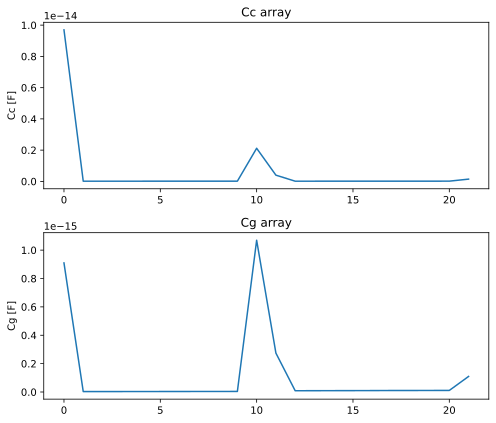

In [23]:
plt.figure(figsize=(7,6))
plt.subplot(2,1,1)
plt.plot(np.arange(len(Cc_array)), Cc_array)
plt.title("Cc array")
plt.ylabel("Cc [F]")
plt.subplot(2,1,2)
plt.plot(np.arange(len(Cg_array)), Cg_array)
plt.title("Cg array")
plt.ylabel("Cg [F]")
plt.tight_layout()
plt.show()

In [24]:
# path = r"C:\Users\gusarov\Desktop\Plasmon_Lumped_chain+trans_CapCalc_Lumped chain+trans_spacingCoupling1um_chainW2.8um_extCouplingW20um_extCouplingL11um_pitW1um_pitL1um_fstLidW10um_fstLidL10um_lastLidW10um_lastLidL10um.csv"

# # N=50
# # path = r"C:\Users\gusarov\Desktop\Plasmon_Lumped_chain+trans_CapCalc_Lumped chain+trans_spacingCoupling1um_chainW2.8um_extCouplingW20um_extCouplingL11um_pitW1um_pitL1um_fstLidW10um_fstLidL10um_lastLidW10um_lastLidL10um_N50.csv"

# Cg_fF, Cc_fF, info = extract_Cg_Cc_simple(path, debug=True)
# Cg_array = np.array(Cg_fF) * fF_to_F
# Cc_array = np.array(Cc_fF) * fF_to_F

# Cc_array_from_N100 = Cc_array[::2]  # Take every other element to match the islands (assuming interleaved)
# Cg_array_from_N100 = Cg_array[::2]  # Take every other element to match the islands (assuming interleaved)

In [25]:
# path = r"C:\Users\gusarov\Desktop\Plasmon_Lumped_chain+trans_CapCalc_Lumped chain+trans_spacingCoupling1um_chainW2.8um_extCouplingW20um_extCouplingL11um_pitW1um_pitL1um_fstLidW10um_fstLidL10um_lastLidW10um_lastLidL10um_N50.csv"

# Cg_fF, Cc_fF, info = extract_Cg_Cc_simple(path, debug=True)
# Cg_array_from_N50 = np.array(Cg_fF) * fF_to_F
# Cc_array_from_N50 = np.array(Cc_fF) * fF_to_F

In [26]:
# Cc_array_from_N50.shape, Cc_array_from_N100.shape

In [27]:
# plt.figure(figsize=(7,6))
# plt.subplot(2,1,1)
# plt.plot(np.arange(len(Cc_array_from_N50)), Cc_array_from_N50, label='N=50')
# plt.plot(np.arange(len(Cc_array_from_N100)), Cc_array_from_N100, label='N=100')
# plt.title("Cc array")
# plt.ylabel("Cc [F]")
# plt.legend()
# plt.subplot(2,1,2)
# plt.plot(np.arange(len(Cg_array_from_N50)), Cg_array_from_N50, label='N=50')
# plt.plot(np.arange(len(Cg_array_from_N100)), Cg_array_from_N100, label='N=100')
# plt.title("Cg array")
# plt.ylabel("Cg [F]")
# plt.legend()
# plt.tight_layout()
# plt.show()

In [28]:
# Cg_array_from_N50[-1], Cc_array_from_N50[-1], Cg_array_from_N100[-1], Cc_array_from_N100[-1]